# Paper artifact builder — single source of truth for every paper number

This notebook regenerates **every table, figure and audit line** in `paper/main.tex` and `paper/supplement.tex` from saved artifacts in `reproducibility/rep_1/` and `paper/tables/`. Re-run it from top to bottom and the paper recompiles bit-identical metrics.

## How the notebook maps to the paper

| Notebook section | Paper artifact | What it shows |
|---|---|---|
| **0. Setup** | — | imports, paths, loads label data |
| **A. Benchmark + model selection** | Table 1 (`tab:leaderboard`), Figure 1 (`fig:leaderboard`), Sup Table S1 | 5×5 RSKF leaderboard across 29 configurations; paired t-tests; identifies `cpu__ET500_log2` as the winner |
| **B. Per-substrate metrics** | Table 2 (`tab:per_substrate`) | per-substrate precision/recall/F1 of the chosen model on the seed-42 5-fold OOF predictions |
| **C. Probability calibration** | Table 3 (`tab:calibration`), Figure 2 (`fig:calibration`) | four calibration protocols; temperature scaling preserves accuracy while halving ECE; sets up the deployable model's probability outputs |
| **D. Per-PUL signature genes via ablation** | Table 4 (`tab:examples`) | leave-one-token-out Δ-prob procedure; six handpicked example PULs with canonical-CAZy hits |
| **E. Per-substrate global signature genes** | Table 5 (`tab:sig_genes`, lit-validated top-3), Table 7 (`tab:lit`, lit validation), Sup Table S2 (unfiltered top-10 with stars) | OvR feature_importances aggregated across folds, filtered to literature-canonical features |
| **F. Population-level lit validation** | Table 4 (sig_val any-hit), Table 4 (lit-gene scope coverage), Sup Tables S4, S5 | two complementary aggregate metrics: per-PUL any-hit (93.2% at K=3 over 776 eligible PULs) and lit-gene scope coverage (99/160 = 61.9% of in-scope canonical genes) |
| **G. Audit trail** | `paper/audit_output.txt` | one line per numeric claim in the paper, with the section that produced it |

## Reproducibility framework (rep_1 / rep_N)

The benchmark numbers in Section A above are loaded from `reproducibility/rep_1/timings/per_fold_metrics.csv`, which is the reference run (5 outer repeats × 5 folds × 29 configurations = 725 trials, finished 2026-05-13). Every (config, seed, fold) trial's classifier weights, test predictions and train predictions are in `reproducibility/rep_1/predictions/<shorthand>/r<seed>_f<fold>/`. To retrain reproducing the same numbers (training=True with the rep_1 cached embeddings), run `python reproducibility/rebuild_paper.py --rep 1 --training True`. To launch a fresh independent run with new seeds/folds/embeddings, run `python reproducibility/rebuild_paper.py --rep 2 --training True`. See `reproducibility/rep_1/README.md`.


In [1]:
# Section 0: imports + paths
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (precision_recall_fscore_support,
                              accuracy_score, confusion_matrix)
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path as _Path
ROOT = str(_Path.cwd().parent if _Path.cwd().name == 'notebooks' else _Path.cwd())
print(f'ROOT = {ROOT}')
PAPER = f'{ROOT}/paper'
FIG = f'{PAPER}/Fig'
TAB = f'{PAPER}/tables'

AUDIT_LINES = []
def audit(label, value):
    """Save a numeric quantity used in the paper to audit_output.txt for traceability."""
    AUDIT_LINES.append(f'{label}\t{value}')
    print(f'  AUDIT: {label} = {value}')

ROOT = /Users/ved/subFinder_May_Release


## Section A — Benchmark and model selection

We evaluate every configuration of the SubFinder published grid (1 BRF baseline + 6 BRF+embedding + 20 DL = 27 paper configs) plus our two shallow ML configs (29 total) under a leak-free 5-repeat × 5-fold Repeated Stratified K-Fold protocol with seeds {42, 43, 44, 45, 46}. The per-fold metrics live in `reproducibility/full_results_perfold.csv` (which mirrors `reproducibility/rep_1/timings/per_fold_metrics.csv`); the cell below ranks the configurations by mean accuracy across the 25 trials and writes Table 1 + Sup Table S1.


## Table 1: 5×5 RSKF leaderboard (top 10 + bottom 1 by overall accuracy)

Source: `reproducibility/full_results_perfold.csv`. Note: 4 of 5 outers complete at time of paper draft; outer 46 in progress.

In [2]:
df = pd.read_csv(f'{ROOT}/artifacts/per_fold_metrics.csv')
n_total = len(df)
audit('csv_rows', n_total)
n_folds_per_seed = df.groupby('repeat_seed')['fold'].nunique().to_dict()
audit('folds_per_seed', n_folds_per_seed)

g = df.groupby(['shorthand', 'family']).agg(
    n=('acc','count'),
    acc_mean=('acc','mean'), acc_std=('acc','std'),
    cw_mean=('classwise','mean'), cw_std=('classwise','std'),
    prec_mean=('precision_macro','mean'),
    rec_mean=('recall_macro','mean'),
    f1_mean=('f1_macro','mean'), f1_std=('f1_macro','std'),
).reset_index().sort_values('acc_mean', ascending=False)

# Top 10 + bottom 1 for the paper table
top10 = g.head(10)
bottom1 = g.tail(1)
paper_lb = pd.concat([top10, bottom1])
paper_lb.to_csv(f'{TAB}/table1_leaderboard.csv', index=False)
audit('top1_config', top10.iloc[0]['shorthand'])
audit('top1_acc', f"{top10.iloc[0]['acc_mean']:.4f}")
audit('top1_acc_std', f"{top10.iloc[0]['acc_std']:.4f}")
audit('top1_n', int(top10.iloc[0]['n']))
audit('top2_config', top10.iloc[1]['shorthand'])
audit('top2_acc', f"{top10.iloc[1]['acc_mean']:.4f}")
audit('paper_baseline_acc', f"{g[g['shorthand']=='cv__BRF100']['acc_mean'].iloc[0]:.4f}")
audit('best_paper_dl_config', g[g['family']=='paper_DL'].iloc[0]['shorthand'])
audit('best_paper_dl_acc', f"{g[g['family']=='paper_DL'].iloc[0]['acc_mean']:.4f}")
audit('gap_ours_vs_paper_baseline', 
      f"{top10.iloc[0]['acc_mean'] - g[g['shorthand']=='cv__BRF100']['acc_mean'].iloc[0]:.4f}")
audit('gap_ours_vs_best_paper_dl',
      f"{top10.iloc[0]['acc_mean'] - g[g['family']=='paper_DL'].iloc[0]['acc_mean']:.4f}")

print(paper_lb[['shorthand','family','n','acc_mean','acc_std','cw_mean','f1_mean']].to_string(index=False))

  AUDIT: csv_rows = 725
  AUDIT: folds_per_seed = {42: 5, 43: 5, 44: 5, 45: 5, 46: 5}
  AUDIT: top1_config = cpu__ET500_log2
  AUDIT: top1_acc = 0.9066
  AUDIT: top1_acc_std = 0.0174
  AUDIT: top1_n = 25
  AUDIT: top2_config = ftCbow_MM__ET500_sqrt
  AUDIT: top2_acc = 0.9010
  AUDIT: paper_baseline_acc = 0.8402
  AUDIT: best_paper_dl_config = ftCbow__LSTMattn
  AUDIT: best_paper_dl_acc = 0.7883
  AUDIT: gap_ours_vs_paper_baseline = 0.0664
  AUDIT: gap_ours_vs_best_paper_dl = 0.1183
            shorthand        family  n  acc_mean  acc_std  cw_mean  f1_mean
      cpu__ET500_log2  ours_shallow 25  0.906602 0.017406      NaN 0.891059
ftCbow_MM__ET500_sqrt  ours_shallow 25  0.900971 0.022465      NaN 0.886661
           cv__BRF100 paper_shallow 25  0.840194 0.025415      NaN 0.819202
       ftCbow__BRF100 paper_shallow 25  0.830097 0.029826      NaN 0.809585
        w2vSg__BRF100 paper_shallow 25  0.816893 0.026311      NaN 0.793063
         ftSg__BRF100 paper_shallow 25  0.814757 0.025328

## Section B — Per-substrate metrics of the chosen model

This section narrows from the 29-config leaderboard to the chosen configuration `cpu__ET500_log2`. The metrics here are evaluated on the seed-42 outer fold's 5-fold OOF predictions (n=1030 PULs total, since every PUL is held out from training in exactly one of the five inner folds). This is the same OOF data used in Sections C and D for calibration and per-PUL ablation.


## Table 2: Per-substrate F1 for cpu__ET500_log2 (outer 42 OOF, n=1030)

Retrain deterministically using cached fold splits; computes precision/recall/F1 per substrate + class size.

In [3]:
df_data = pd.read_csv(f'{ROOT}/data/Train_data.csv')
y = df_data['high_level_substr'].values
X = df_data['sig_gene_seq'].values
substrates = sorted(set(y))
class_size = {s: int((y==s).sum()) for s in substrates}

def tok_cpu(s): return [t for t in re.split(r'[,|_]', str(s)) if t]

# Derive seed-42 5-fold splits locally — identical to what artifacts/embeddings_cache/r42_f*/splits.npz stores.
# Means this cell works without downloading the embeddings cache (top model uses no embeddings anyway).
from sklearn.model_selection import StratifiedKFold as _SKF7
rows = []
for fold, (otr, te) in enumerate(_SKF7(n_splits=5, shuffle=True, random_state=42).split(X, y)):
    cv = CountVectorizer(tokenizer=tok_cpu, lowercase=False, token_pattern=None, ngram_range=(1,1))
    Xtr = cv.fit_transform(X[otr]); Xte = cv.transform(X[te])
    clf = OneVsRestClassifier(ExtraTreesClassifier(
        n_estimators=500, max_features='log2', class_weight='balanced',
        bootstrap=False, n_jobs=-1, random_state=42))
    clf.fit(Xtr, y[otr]); yp = clf.predict(Xte)
    p, r, f, s = precision_recall_fscore_support(y[te], yp, labels=substrates, average=None, zero_division=0)
    cm = confusion_matrix(y[te], yp, labels=substrates, normalize='true')
    for i, sub in enumerate(substrates):
        rows.append({'substrate': sub, 'class_size': class_size[sub],
                      'fold': fold, 'precision': p[i], 'recall': r[i], 'f1': f[i],
                      'class_acc': float(cm[i,i]) if not np.isnan(cm[i,i]) else 0.0,
                      'support_in_te': int(s[i])})
rd = pd.DataFrame(rows)
agg = rd.groupby(['substrate','class_size']).agg(
    precision=('precision', lambda x: f'{x.mean():.3f} ± {x.std():.3f}'),
    recall=('recall',    lambda x: f'{x.mean():.3f} ± {x.std():.3f}'),
    f1=('f1',           lambda x: f'{x.mean():.3f} ± {x.std():.3f}'),
    class_acc=('class_acc',lambda x: f'{x.mean():.3f} ± {x.std():.3f}'),
    avg_support=('support_in_te','mean'),
    f1_mean=('f1','mean'),
).reset_index().sort_values('class_size', ascending=False)
agg.drop(columns=['f1_mean']).to_csv(f'{TAB}/table2_per_substrate.csv', index=False)
print(agg.to_string(index=False))
audit('alginate_f1', f"{rd[rd['substrate']=='alginate']['f1'].mean():.3f}")
audit('alpha_mannan_f1', f"{rd[rd['substrate']=='alpha-mannan']['f1'].mean():.3f}")
audit('fructan_f1', f"{rd[rd['substrate']=='fructan']['f1'].mean():.3f}")

      substrate  class_size     precision        recall            f1     class_acc  avg_support  f1_mean
    host glycan         240 0.922 ± 0.049 0.963 ± 0.023 0.941 ± 0.035 0.963 ± 0.023         48.0 0.941365
   alpha-glucan         128 0.910 ± 0.033 0.945 ± 0.060 0.927 ± 0.042 0.945 ± 0.060         25.6 0.926756
    beta-glucan         123 0.890 ± 0.029 0.911 ± 0.043 0.899 ± 0.021 0.911 ± 0.043         24.6 0.899392
         pectin         102 0.935 ± 0.074 0.902 ± 0.048 0.916 ± 0.035 0.902 ± 0.048         20.4 0.916138
          xylan          97 0.931 ± 0.056 0.937 ± 0.069 0.932 ± 0.040 0.937 ± 0.069         19.4 0.932048
       galactan          72 0.812 ± 0.111 0.776 ± 0.120 0.792 ± 0.108 0.776 ± 0.120         14.4 0.791974
    beta-mannan          68 0.790 ± 0.127 0.795 ± 0.092 0.789 ± 0.095 0.795 ± 0.092         13.6 0.789036
         chitin          63 0.937 ± 0.062 0.887 ± 0.073 0.910 ± 0.053 0.887 ± 0.073         12.6 0.909509
       alginate          48 1.000 ± 0.000 1.00

## Figure 1: 5×5 RSKF leaderboard barplot (top 15)

In [4]:
top15 = g.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(top15))
colors = ['darkgreen' if 'ours' in row['family'] else ('steelblue' if 'BRF100' in row['shorthand'] or 'BRF' in row['shorthand'] else 'sandybrown') for _, row in top15.iterrows()]
ax.barh(y_pos, top15['acc_mean'].values, xerr=top15['acc_std'].values, color=colors, alpha=0.85, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top15['shorthand'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0.55, 1.0)
ax.set_xlabel('Mean test accuracy (5×5 RSKF)', fontsize=11)
ax.axvline(top15.iloc[0]['acc_mean'], color='red', linestyle='--', alpha=0.5, label='best')
ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='darkgreen', label='our shallow ML'),
                    Patch(facecolor='steelblue', label='paper shallow ML'),
                    Patch(facecolor='sandybrown', label='paper DL')], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG}/fig1_leaderboard.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved fig1_leaderboard.png')

Saved fig1_leaderboard.png


## Section C — Probability calibration for deployable inference

The chosen model returns per-substrate probabilities via `predict_proba`. The raw probabilities are diffuse (the OvR ExtraTrees output spans `[0.2, 0.8]` more than `[0, 1]`) so we calibrate. This section compares four protocols on the seed-42 OOF predictions:
1. Uncalibrated
2. Temperature scaling (a single scalar T fit by internal 5-fold CV on the outer-train fold)
3. Per-class isotonic (`CalibratedClassifierCV(cv=5)`)
4. Per-class sigmoid/Platt (`CalibratedClassifierCV(cv=5)`)

Temperature scaling at T = 0.85 preserves all argmax predictions while halving ECE — the deployable inference pipeline uses this. See main paper §2.5.


## Table 3: Calibration analysis on outer 42 OOF (n=1030)

Three calibration protocols compared. Pulls precomputed prob arrays from `oof_outer42_*.npz`.

In [5]:
le = LabelEncoder(); le.fit(y)
y_enc = le.transform(y)

def compute_ece(probs, labels, n_bins=10):
    pred = probs.argmax(axis=1); conf = probs.max(axis=1)
    correct = (pred == labels).astype(float)
    edges = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        mask = (conf >= lo) & (conf < hi) if i < n_bins-1 else (conf >= lo) & (conf <= hi)
        if mask.sum() == 0: continue
        ece += (mask.sum()/len(probs)) * abs(correct[mask].mean() - conf[mask].mean())
    return ece

def compute_brier(probs, labels):
    K = probs.shape[1]
    one_hot = np.zeros((len(labels), K)); one_hot[np.arange(len(labels)), labels] = 1
    return ((probs - one_hot) ** 2).sum(axis=1).mean()

cal_best = np.load(f'{ROOT}/artifacts/calibration/oof_outer42_best_of_both.npz', allow_pickle=True)
cal_cv5  = np.load(f'{ROOT}/artifacts/calibration/oof_outer42_calibration.npz', allow_pickle=True)

rows_cal = [
    ('Uncalibrated (full outer_tr trained)',     cal_best['probs_uncal'], y_enc),
    ('Temperature scaling (T fit via inner-CV)', cal_best['probs_temp'],  y_enc),
    ('Isotonic (CalibratedClassifierCV cv=5)',   cal_cv5['probs_iso'],    y_enc),
    ('Sigmoid/Platt (CalibratedClassifierCV cv=5)', cal_cv5['probs_sig'], y_enc),
]
cal_table = []
for label, probs, lbl in rows_cal:
    acc = (probs.argmax(axis=1) == lbl).mean()
    ece = compute_ece(probs, lbl); brier = compute_brier(probs, lbl)
    cal_table.append({'method': label, 'accuracy': acc, 'ECE_10bin': ece, 'Brier': brier})
    print(f"  {label:<45}  acc={acc:.4f}  ECE={ece:.4f}  Brier={brier:.4f}")
    audit(f'cal_{label[:20]}_acc', f'{acc:.4f}')
    audit(f'cal_{label[:20]}_ECE', f'{ece:.4f}')

pd.DataFrame(cal_table).to_csv(f'{TAB}/table3_calibration.csv', index=False)
audit('mean_T', f"{np.mean(cal_best['T_per_fold']):.4f}")


  Uncalibrated (full outer_tr trained)           acc=0.9029  ECE=0.0941  Brier=0.1801
  AUDIT: cal_Uncalibrated (full o_acc = 0.9029
  AUDIT: cal_Uncalibrated (full o_ECE = 0.0941
  Temperature scaling (T fit via inner-CV)       acc=0.9029  ECE=0.0293  Brier=0.1585
  AUDIT: cal_Temperature scaling _acc = 0.9029
  AUDIT: cal_Temperature scaling _ECE = 0.0293
  Isotonic (CalibratedClassifierCV cv=5)         acc=0.8903  ECE=0.0398  Brier=0.1655
  AUDIT: cal_Isotonic (Calibrated_acc = 0.8903
  AUDIT: cal_Isotonic (Calibrated_ECE = 0.0398
  Sigmoid/Platt (CalibratedClassifierCV cv=5)    acc=0.9019  ECE=0.1525  Brier=0.1822
  AUDIT: cal_Sigmoid/Platt (Calib_acc = 0.9019
  AUDIT: cal_Sigmoid/Platt (Calib_ECE = 0.1525
  AUDIT: mean_T = 0.6996


## Figure 2: Reliability diagram before vs after calibration

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, label, probs in [(axes[0], 'Uncalibrated', cal_best['probs_uncal']),
                           (axes[1], f'Temperature scaling (mean T = {np.mean(cal_best["T_per_fold"]):.2f})', cal_best['probs_temp'])]:
    ece = compute_ece(probs, y_enc, n_bins=10)
    pred = probs.argmax(axis=1); conf = probs.max(axis=1)
    correct = (pred == y_enc).astype(float)
    edges = np.linspace(0, 1, 11)
    bm, n_arr, accs, confs = [], [], [], []
    for i in range(10):
        lo, hi = edges[i], edges[i+1]
        mask = (conf >= lo) & (conf < hi) if i < 9 else (conf >= lo) & (conf <= hi)
        if mask.sum() > 0:
            bm.append((lo+hi)/2); n_arr.append(int(mask.sum())); accs.append(correct[mask].mean()); confs.append(conf[mask].mean())
    bm,n_arr,accs,confs = map(np.array, [bm,n_arr,accs,confs])
    ax.bar(bm, accs, width=0.08, alpha=0.6, color='steelblue', edgecolor='black', label='accuracy')
    ax.plot([0,1],[0,1],'k--',linewidth=1.5, label='perfect')
    ax.scatter(bm, confs, s=np.sqrt(n_arr)*15, color='orange', edgecolor='red', zorder=5, label='mean conf')
    for x,a,n in zip(bm,accs,n_arr): ax.text(x, min(a+0.03,1.05), f'n={n}', ha='center', fontsize=8)
    ax.set_xlim(0,1.05); ax.set_ylim(0,1.10)
    ax.set_xlabel('Predicted confidence', fontsize=11)
    if ax is axes[0]: ax.set_ylabel('Empirical accuracy', fontsize=11)
    ax.set_title(f'{label} — ECE = {ece:.4f}', fontsize=11)
    ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Reliability diagram — cpu__ET500_log2 on outer 42 OOF (n=1030)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/fig2_calibration.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved fig2_calibration.png')

Saved fig2_calibration.png


## Section E — Per-substrate global signature genes via OvR feature_importances

For each of the 12 OvR binary classifiers, we average the trained ExtraTrees `feature_importances_` across the five inner cross-validation folds of seed 42. The top features by importance are the global signature-gene candidates for that substrate. Two views are saved:
- `table4_signature_genes_per_substrate.csv`: raw top-10 by importance (used in Sup Table S2 with canonical * markers).
- `table6b_sig_genes_lit_validated.csv`: top-3 restricted to literature-canonical features (used in main paper Table 5).
- `table6c_sig_genes_top10_unfiltered_starred.csv`: top-10 unfiltered with star markers on canonical (Sup Table S2 source).


## Table 4: Global signature genes per substrate via OvR(ET).feature_importances_

For each substrate's OvR binary tree, extract top-N global features. Cross-validated across 5 folds.

In [7]:
from collections import defaultdict
fi_avg = defaultdict(lambda: defaultdict(float))
# Derive seed-42 5-fold splits locally (same protocol as the cache; no download required).
from sklearn.model_selection import StratifiedKFold as _SKF17
for fold, (otr, te) in enumerate(_SKF17(n_splits=5, shuffle=True, random_state=42).split(X, y)):
    cv = CountVectorizer(tokenizer=tok_cpu, lowercase=False, token_pattern=None, ngram_range=(1,1))
    Xtr = cv.fit_transform(X[otr])
    feature_names = cv.get_feature_names_out()
    clf = OneVsRestClassifier(ExtraTreesClassifier(
        n_estimators=500, max_features='log2', class_weight='balanced',
        bootstrap=False, n_jobs=-1, random_state=42))
    clf.fit(Xtr, y[otr])
    for sub, est in zip(clf.classes_, clf.estimators_):
        fi = est.feature_importances_
        for f_name, val in zip(feature_names, fi):
            fi_avg[sub][f_name] += val / 5

TOP_N = 10
sig_rows = []
for sub in substrates:
    sorted_feats = sorted(fi_avg[sub].items(), key=lambda x: -x[1])[:TOP_N]
    for rank, (f_name, imp) in enumerate(sorted_feats, 1):
        sig_rows.append({'substrate': sub, 'rank': rank, 'feature': f_name, 'importance': imp})
sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv(f'{TAB}/table4_signature_genes_per_substrate.csv', index=False)
print(sig_df.to_string(index=False))

      substrate  rank     feature  importance
       alginate     1        PL17    0.125491
       alginate     2         PL6    0.110405
       alginate     3        GntR    0.065448
       alginate     4           1    0.051416
       alginate     5         PL7    0.048610
       alginate     6     binding    0.039167
       alginate     7         PL5    0.033178
       alginate     8 2.A.1.14.25    0.032079
       alginate     9        PfkB    0.030653
       alginate    10           2    0.026935
   alpha-glucan     1        GH13    0.093694
   alpha-glucan     2        LacI    0.058457
   alpha-glucan     3        GH97    0.047114
   alpha-glucan     4        GH32    0.029106
   alpha-glucan     5         HTH    0.027132
   alpha-glucan     6        AraC    0.026294
   alpha-glucan     7        null    0.024968
   alpha-glucan     8        GH66    0.019334
   alpha-glucan     9        GT35    0.019010
   alpha-glucan    10   2.A.1.5.3    0.015659
   alpha-mannan     1        GH99 

In [8]:
import re as _re_split
def _split_lit_substr(s):
    return [p.strip() for p in _re_split.split(r",|and\s+", str(s)) if p.strip()]
def _build_canon(lit_df, alias_map):
    canon = {s: set() for s in alias_map}
    for _, row in lit_df.iterrows():
        parts = _split_lit_substr(row["Substrate_high_level"])
        for our_sub, aliases in alias_map.items():
            if set(aliases) & set(parts):
                canon[our_sub].add(row["Family"])
    return canon

# Table 6b: lit-validated per-substrate top-3 (top-3 by Gini restricted to lit-canon)
# This is the "no-cheating" version of the per-substrate global signature genes:
# we filter to features that are in the curated CAZy literature mapping for that substrate.
# get_canonical_families is defined in the literature-validation cell that runs next; we
# re-fetch via the same alias map here so this cell is self-contained.
lit_tmp = pd.read_csv(f'{ROOT}/data/Literature_Data_fam_substrate_mapping.tsv', sep='\t')
lit_tmp.columns = [c.strip() for c in lit_tmp.columns]
SA_TMP = {
    'alpha-glucan':['alpha-glucan','starch','glycogen','sucrose','raffinose','trehalose','palatinose','glucooligosaccharide'],
    'beta-glucan':['beta-glucan','cellulose','cellooligosaccharide','xyloglucan','beta-glycan'],
    'galactan':['galactan','beta-galactan','alpha-galactan'],
    'arabinogalactan':['arabinogalactan','arabinogalactan protein','arabinan'],
    'host glycan':['host glycan','human-milk-polysaccharide','human milk polysaccharide','sialic-acid','sialic acid','fucose'],
    'chitin':['chitin','chitooligosaccharide','chitosan'],
    'alginate':['alginate'],'pectin':['pectin'],'xylan':['xylan'],
    'alpha-mannan':['alpha-mannan'],'beta-mannan':['beta-mannan'],'fructan':['fructan']}
canon_tmp = _build_canon(lit_tmp, SA_TMP)
fi = pd.read_csv(f'{TAB}/table4_signature_genes_per_substrate.csv')
out_rows = []
for s in substrates:
    fs = fi[fi['substrate']==s].sort_values('importance', ascending=False).reset_index(drop=True)
    fs['rank'] = fs.index + 1
    lit_only = fs[fs['feature'].isin(canon_tmp[s])].head(3)
    items = [f"{r['feature']} (r{int(r['rank'])})" for _, r in lit_only.iterrows()]
    while len(items) < 3: items.append('—')
    out_rows.append({'substrate': s, 'lit_canon_size': len(canon_tmp[s]),
                      'lit_validated_top3': '; '.join(items)})
pd.DataFrame(out_rows).to_csv(f'{TAB}/table6b_sig_genes_lit_validated.csv', index=False)
print('Lit-validated per-substrate top-3 (overall-rank in parens):')
for r in out_rows: print(f"  {r['substrate']:<18}(lit={r['lit_canon_size']}): {r['lit_validated_top3']}")


# Table 6c: top-10 UNFILTERED per substrate with canonical markers (companion to Table 6b).
# Lists ALL features in importance order, marking those in the literature canonical set with *.
# Used as the Supplementary Table S2 in the paper.
rows_c = []
for s in substrates:
    fs = fi[fi['substrate']==s].sort_values('importance', ascending=False).reset_index(drop=True)
    fs['rank'] = fs.index + 1
    top10 = fs.head(10)
    items = [f"{r['feature']}{'*' if r['feature'] in canon_tmp[s] else ''}(r{int(r['rank'])})"
             for _, r in top10.iterrows()]
    rows_c.append({'substrate': s, 'lit_canon_size': len(canon_tmp[s]),
                    'top10_with_stars': ', '.join(items)})
pd.DataFrame(rows_c).to_csv(f'{TAB}/table6c_sig_genes_top10_unfiltered_starred.csv', index=False)
print('\nUnfiltered top-10 with canonical markers (* = lit-canonical):')
for r in rows_c: print(f"  {r['substrate']:<18}(lit={r['lit_canon_size']}): {r['top10_with_stars']}")


Lit-validated per-substrate top-3 (overall-rank in parens):
  alginate          (lit=12): PL17 (r1); PL6 (r2); PL7 (r5)
  alpha-glucan      (lit=41): GH13 (r1); GH97 (r3); GH66 (r8)
  alpha-mannan      (lit=7): GH99 (r1); GH125 (r3); GH76 (r4)
  arabinogalactan   (lit=22): GH51 (r1); GH43 (r2); GH146 (r10)
  beta-glucan       (lit=87): GH3 (r1); GH1 (r2); GH5 (r4)
  beta-mannan       (lit=18): GH26 (r1); GH130 (r2); —
  chitin            (lit=36): GH18 (r5); AA10 (r8); —
  fructan           (lit=6): GH32 (r1); GH68 (r6); —
  galactan          (lit=17): GH36 (r7); GH2 (r9); —
  host glycan       (lit=65): CE9 (r1); CBM32 (r3); GH20 (r4)
  pectin            (lit=33): GH28 (r1); PL1 (r2); GH105 (r3)
  xylan             (lit=51): GH10 (r1); GH43 (r2); GH67 (r3)

Unfiltered top-10 with canonical markers (* = lit-canonical):
  alginate          (lit=12): PL17*(r1), PL6*(r2), GntR(r3), 1(r4), PL7*(r5), binding(r6), PL5*(r7), 2.A.1.14.25(r8), PfkB(r9), 2(r10)
  alpha-glucan      (lit=41): GH13

## Section E.2 — Literature validation of the top-3 features per substrate

We compare the top-3 features per substrate against a manually curated CAZy literature mapping (`Data/Literature_Data_fam_substrate_mapping.tsv`, 753 raw entries / 75 substrate categories collapsed via the alias map to 351 (substrate, CAZy family) pairs across our 12 classes). 21 of 36 model top-3 features (58%) are canonical for their predicted substrate. The alias map is grounded in primary-literature citations (Burton 2006, Stam 2006, Marcobal 2011, etc.) — see Methods §2.9 and Supplementary Table S3.


## Table 5: Literature validation of top-3 signature genes per substrate

**Substrate-alias map — literature support.** The curated CAZy literature mapping uses a 75-category substrate vocabulary that is finer than our 12-class output. Before any comparison we collapse those 75 categories into our 12 classes via an alias map grounded in primary literature (shared backbone-linkage chemistry and shared CAZy-family enzyme repertoire), not editorial judgement. Each non-trivial alias group is cited below; the citations appear in `paper/reference.bib` and are cross-referenced in Methods §2.9 of `main.tex`.

| output class | lit names absorbed | citation |
|---|---|---|
| beta-glucan | cellulose, cellooligosaccharide, xyloglucan, beta-glycan | Burton et al. 2006 *Science* (cellulose / mixed-linkage β-glucan biosynthesis); Eklof & Brumer 2010 *Plant Physiology* (xyloglucan ↔ cellulose enzyme-family overlap) |
| alpha-glucan | starch, glycogen, sucrose, raffinose, trehalose, palatinose, glucooligosaccharide | Stam et al. 2006 *Protein Eng. Des. Sel.* (GH13 subfamilies); Janecek et al. 2014 *Cell. Mol. Life Sci.* (α-amylase EC 3.2.1.1 substrate scope) |
| arabinogalactan | arabinan, arabinogalactan protein | Tan et al. 2013 *The Plant Cell* (AGP–arabinoxylan covalent linkage); Showalter et al. 2010 *Plant Physiology* (AGP bioinformatic classification) |
| host glycan | human-milk-polysaccharide, sialic-acid, fucose | Marcobal et al. 2011 *Cell Host & Microbe* (Bacteroides HMO/mucin pathway); Tailford et al. 2015 *Frontiers in Genetics* (mucin glycan foraging) |
| chitin | chitosan, chitooligosaccharide | Hartl et al. 2012 *Appl. Microbiol. Biotechnol.* (GH18/GH19 chitinases); Adrangi & Faramarzi 2013 *Biotechnology Advances* (chitin / chitosan / oligo substrate scope) |
| galactan | alpha-galactan, beta-galactan | CAZy DB (Lombard et al. 2014 *NAR*) — alpha/beta refer to glycosidic-linkage anomericity of the same galactan superclass |
| alginate, pectin, xylan, alpha-mannan, beta-mannan, fructan | (exact match — no aliasing) | CAZy DB (Lombard et al. 2014 *NAR*) |

Lit substrate categories with no counterpart in our 12 output classes (lignin, agar, fucoidan, etc.) are dropped because the model cannot predict them.


In [9]:
# === CORRECTED substrate alias map (post-paper review) ===
# Drops "beta-fucosides" (was wrong — fucose-linked, not glucose-linked).
# Adds multi-substrate row splitting so that rows like "cellulose, chitin"
# credit the gene to BOTH cellulose (→ beta-glucan) AND chitin.
SUBSTRATE_ALIAS = {
    "alpha-glucan":    ["alpha-glucan","starch","glycogen","sucrose","raffinose","trehalose","palatinose","glucooligosaccharide"],
    "beta-glucan":     ["beta-glucan","cellulose","cellooligosaccharide","xyloglucan","beta-glycan"],   # removed beta-fucosides
    "galactan":        ["beta-galactan","alpha-galactan"],
    "arabinogalactan": ["arabinogalactan protein","arabinan"],
    "host glycan":     ["host glycan","human-milk-polysaccharide","human milk polysaccharide","sialic-acid","sialic acid","fucose"],
    "chitin":          ["chitin","chitooligosaccharide","chitosan"],
    "alginate":["alginate"],"pectin":["pectin"],"xylan":["xylan"],
    "alpha-mannan":["alpha-mannan"],"beta-mannan":["beta-mannan"],"fructan":["fructan"],
}
import re as _re
def _canon_set(s, lit_df, alias_map=SUBSTRATE_ALIAS):
    """Return the set of CAZy families canonical for substrate s.
    Multi-substrate rows like 'cellulose, chitin' get split + assigned to each."""
    out = set()
    aliases = set(alias_map.get(s, [s]))
    for _, row in lit_df.iterrows():
        parts = [p.strip() for p in _re.split(r",|and\s+", str(row["Substrate_high_level"])) if p.strip()]
        if aliases & set(parts):
            out.add(row["Family"])
    return out
def get_canonical_families(sub, lit_df=None):
    """Compatible wrapper used by the rest of the notebook."""
    if lit_df is None:
        global lit
        return _canon_set(sub, lit)
    return _canon_set(sub, lit_df)

lit = pd.read_csv(f'{ROOT}/data/Literature_Data_fam_substrate_mapping.tsv', sep='\t')
lit.columns = [c.strip() for c in lit.columns]

# Substrate name aliasing — map literature names to our 12-class space



val_rows = []
for sub in substrates:
    canon = get_canonical_families(sub)
    top3 = sig_df[sig_df['substrate']==sub].head(3)['feature'].tolist()
    # Match: signature feature is canonical if it's exactly in canon set (e.g., 'GH28' matches)
    # or its family prefix matches (e.g., signature 'GH28_5' matches canonical 'GH28' family)
    n_match = 0
    matched = []
    for t in top3:
        # exact match in canon
        if t in canon: n_match += 1; matched.append((t, 'exact')); continue
        # family-level: if our token like '28' came from CountVec_cpu split of 'GH28_5', check membership of any CAZy family that prefixes
        # Note: since we used tok_cpu (split on _), `GH28` exists as a separate feature; numbers like `28` alone don't match canonicals
        match_fam = next((f for f in canon if t == f.split('_')[0]), None)
        if match_fam:
            n_match += 1; matched.append((t, f'family({match_fam})'))
    val_rows.append({'substrate': sub, 'class_size': class_size[sub],
                      'top3_features': ', '.join(top3),
                      'n_canonical_in_top3': n_match,
                      'canonical_match_details': '; '.join(f'{t}:{w}' for t,w in matched),
                      'n_literature_entries': len(canon)})
vdf = pd.DataFrame(val_rows)
vdf.to_csv(f'{TAB}/table5_literature_validation.csv', index=False)
print(vdf.to_string(index=False))
audit('total_canonical_in_top3', int(vdf['n_canonical_in_top3'].sum()))
audit('total_possible_top3', 3*12)

      substrate  class_size             top3_features  n_canonical_in_top3            canonical_match_details  n_literature_entries
       alginate          48           PL17, PL6, GntR                    2              PL17:exact; PL6:exact                    12
   alpha-glucan         128          GH13, LacI, GH97                    2             GH13:exact; GH97:exact                    41
   alpha-mannan          22         GH99, GH92, GH125                    2            GH99:exact; GH125:exact                     7
arabinogalactan          36            GH51, GH43, 24                    2             GH51:exact; GH43:exact                    21
    beta-glucan         123               GH3, GH1, 4                    2               GH3:exact; GH1:exact                    87
    beta-mannan          68         GH26, GH130, GH42                    2            GH26:exact; GH130:exact                    18
         chitin          63 GH4, 4.A.3.2.1, 4.A.3.2.7                    0  

## Section D — Per-PUL signature genes via leave-one-token-out ablation

The ablation procedure: for each PUL, predict probabilities, then for every unique token remove all its occurrences and re-predict — the Δ-prob for the predicted-class column is the token's contribution. Positive Δ tokens ranked descending are the per-PUL signature genes. Cost: N+1 predict_proba calls per PUL (~5 sec/fold when batched via one giant sparse predict_proba over all (PUL, token) ablation rows; ~70 sec/fold for the naïve per-PUL loop). Six handpicked example PULs are written to `table6_example_predictions.csv` with stars marking canonical-CAZy hits.


## Table 6: Example ablation Δ-prob signature genes per PUL (sample of 5)

In [10]:
# Section 6: Per-PUL ablation Δ-prob signature genes — BATCHED (5-fold OOF for seed-42).
# Builds one giant ablated CountVec matrix per fold and calls predict_proba ONCE per fold.
# ~3-5 sec/fold vs ~70 sec/fold for the per-PUL inner loop.
from sklearn.model_selection import StratifiedKFold
from scipy import sparse

CAZY_PREFIX_RE = re.compile(r'^(GH|GT|PL|CE|CBM|AA)[0-9]+$')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_rows = []
for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    cv = CountVectorizer(tokenizer=tok_cpu, lowercase=False, token_pattern=None, ngram_range=(1,1))
    Xtr = cv.fit_transform(X[tr_idx]); Xte = cv.transform(X[te_idx]).tocsr()
    inv_vocab = {v:k for k,v in cv.vocabulary_.items()}
    clf = OneVsRestClassifier(ExtraTreesClassifier(
        n_estimators=500, max_features='log2', class_weight='balanced',
        bootstrap=False, n_jobs=-1, random_state=42))
    clf.fit(Xtr, y[tr_idx])
    classes_list = list(clf.classes_)
    P = clf.predict_proba(Xte); pred = P.argmax(1)
    rows_mod, meta = [], []
    for i_local in range(Xte.shape[0]):
        row = Xte.getrow(i_local)
        for col_i in row.nonzero()[1]:
            mod = row.tolil(); mod[0, col_i] = 0
            rows_mod.append(mod.tocsr()); meta.append((i_local, inv_vocab[col_i]))
    big = sparse.vstack(rows_mod) if rows_mod else sparse.csr_matrix((0, Xte.shape[1]))
    Pa = clf.predict_proba(big)
    i_m = 0
    for i_local, gl in enumerate(te_idx):
        ci = pred[i_local]; p0 = P[i_local, ci]
        pul_toks = []
        while i_m < len(meta) and meta[i_m][0] == i_local:
            pul_toks.append((meta[i_m][1], p0 - Pa[i_m, ci]))
            i_m += 1
        pos = sorted([(t,d) for t,d in pul_toks if d>0], key=lambda x: -x[1])[:5]
        all_rows.append({'idx': int(gl), 'fold': fold_idx,
                          'true': y[gl], 'pred': classes_list[ci],
                          'prob': float(p0),
                          'top1': pos[0][0] if pos else '',
                          'top3': ';'.join(t for t,_ in pos[:3]),
                          'top5': ';'.join(t for t,_ in pos[:5]),
                          'top5_with_delta': ';'.join(f'{t}:{d:+.4f}' for t,d in pos[:5])})
oof = pd.DataFrame(all_rows)
oof.to_csv(f'{TAB}/sig_gene_ablation_oof_outer42.csv', index=False)
print(f'Per-PUL ablation OOF saved: {len(oof)} rows  (correct: {(oof["true"]==oof["pred"]).sum()})')

fold0 = oof[oof['fold']==0].copy()
fold0['top5_list'] = fold0['top5'].fillna('').apply(lambda s: s.split(';') if s else [])

# Re-train one model on fold 0 and recompute Δ-values for handpicked rows
tr_idx, te_idx = next(skf.split(X, y))
cv = CountVectorizer(tokenizer=tok_cpu, lowercase=False, token_pattern=None)
Xtr = cv.fit_transform(X[tr_idx]); Xte = cv.transform(X[te_idx]).tocsr()
inv_vocab = {v:k for k,v in cv.vocabulary_.items()}
clf = OneVsRestClassifier(ExtraTreesClassifier(
    n_estimators=500, max_features='log2', class_weight='balanced',
    bootstrap=False, n_jobs=-1, random_state=42))
clf.fit(Xtr, y[tr_idx]); classes_list = list(clf.classes_)
P = clf.predict_proba(Xte); pred = P.argmax(1)
rows_mod, meta = [], []
for i_local in range(Xte.shape[0]):
    row = Xte.getrow(i_local)
    for col_i in row.nonzero()[1]:
        mod = row.tolil(); mod[0, col_i] = 0
        rows_mod.append(mod.tocsr()); meta.append((i_local, inv_vocab[col_i]))
big = sparse.vstack(rows_mod); Pa = clf.predict_proba(big)
te_map = {int(g): i for i,g in enumerate(te_idx)}

TARGETS = ['alginate','alpha-mannan','xylan','pectin','chitin','host glycan']
picks = []
for sub in TARGETS:
    cs = get_canonical_families(sub)
    rows = fold0[(fold0['pred']==sub) & (fold0['true']==sub)].copy()
    rows['n_canon_in_top3'] = rows['top5_list'].apply(lambda l: sum(1 for t in l[:3] if t in cs))
    rows['n_canon_in_top5'] = rows['top5_list'].apply(lambda l: sum(1 for t in l[:5] if t in cs))
    rows = rows.sort_values(['n_canon_in_top3','n_canon_in_top5','prob'], ascending=[False,False,False])
    best = rows.iloc[0]
    i_local = te_map[int(best['idx'])]; ci = pred[i_local]; p0 = P[i_local, ci]
    pul_toks = [(t, p0 - Pa[j, ci]) for j,(il,t) in enumerate(meta) if il==i_local]
    pos = sorted([(t,d) for t,d in pul_toks if d>0], key=lambda x: -x[1])[:5]
    sigs = '; '.join(f'{t}{"*" if t in cs else ""}:{d:+.4f}' for t,d in pos)
    pval = (1-p0)**11
    picks.append({'idx': int(best['idx']), 'true_substrate': best['true'],
                   'predicted_substrate': best['pred'], 'predicted_prob': round(float(p0),4),
                   'p_value': f'{pval:.2e}', 'top5_signature_genes': sigs,
                   'canon_in_top3': int(best['n_canon_in_top3']),
                   'curated_canon_set_size': len(cs)})
exdf = pd.DataFrame(picks)
exdf.to_csv(f'{TAB}/table6_example_predictions.csv', index=False)
print('\nHandpicked examples:')
print(exdf[['idx','true_substrate','predicted_prob','top5_signature_genes','canon_in_top3','curated_canon_set_size']].to_string(index=False))
audit('handpicked_examples_with_canonical_match_in_top3', int(exdf['canon_in_top3'].sum()))
audit('handpicked_examples_count', len(exdf))


Per-PUL ablation OOF saved: 1030 rows  (correct: 930)



Handpicked examples:
 idx true_substrate  predicted_prob                                                      top5_signature_genes  canon_in_top3  curated_canon_set_size
  11       alginate          1.0000           PL17*:+0.1947; PL6*:+0.1263; GntR:+0.1113; 1:+0.0904; 2:+0.0656              2                      12
 177   alpha-mannan          0.9558    GH125*:+0.2757; GH1:+0.2676; GH38*:+0.2384; GntR:+0.2325; GH84:+0.2181              2                       7
 934          xylan          0.8635      GH10*:+0.1703; GH67*:+0.0898; GH43*:+0.0632; GH5*:+0.0588; 1:+0.0474              3                      51
 851         pectin          0.8537 GH28*:+0.0976; GH105*:+0.0818; PL10*:+0.0678; CE8*:+0.0672; CE12*:+0.0596              3                      33
 439         chitin          1.0000  AA10*:+0.3379; GH18*:+0.1742; 1:+0.1353; HTH:+0.0982; 1.E.2.1.11:+0.0435              2                      36
 601    host glycan          0.8951  GH20*:+0.0478; GH33*:+0.0388; GH2*:+0.0377; CBM

## Section F — Population-level signature-gene validation (two complementary metrics)

Handpicked examples are easy to cherry-pick. To validate the per-PUL ablation procedure at the population level, we compute two aggregate metrics over all 1030 OOF PULs of seed 42 (930 correctly classified):

1. **Per-PUL any-hit**: of 776 eligible PULs (correctly classified AND contain ≥1 lit-canonical CAZy for the true substrate), fraction where top-K ablation includes ≥1 canonical. K=3: 93.2% (723/776).

2. **Lit-gene scope coverage**: of 160 in-scope (substrate, canonical-CAZy-gene) pairs (canonical genes that actually appear in ≥1 test PUL), fraction the model surfaces as top-K Δ-prob anywhere in the population. K=3: 61.9% (99/160).


## Table 7: Aggregate signature-gene validation metrics (5-fold OOF, seed 42)

Hit-rate@K: fraction of correctly-predicted PULs whose top-K ablation Δ-prob tokens include ≥1 canonical CAZy family for the predicted substrate (after substrate-alias collapse of the 753-entry curated DB to 12 output classes). Eligible-only restricts the denominator to PULs that actually contain ≥1 canonical CAZy for the predicted substrate, so the curated DB has a chance to match.


In [11]:
oof = pd.read_csv(f'{TAB}/sig_gene_ablation_oof_outer42.csv')
agg_rows = []
for restrict, label in [(False, 'all_correct'), (True, 'eligible_only')]:
    sub = oof[oof['true']==oof['pred']]
    for K in [1,3,5]:
        n=0; hit=0
        for _, r in sub.iterrows():
            cs = get_canonical_families(r['pred'])
            pul = set(tok_cpu(X[r['idx']]))
            elig = bool(pul & cs)
            if restrict and not elig: continue
            n += 1
            topk = r['top5'].split(';')[:K] if isinstance(r['top5'], str) else []
            if set(topk) & cs: hit += 1
        agg_rows.append({'denominator': label, 'K': K, 'n_denom': n,
                          'n_hit': hit, 'hit_rate': hit/n if n else 0})
agg = pd.DataFrame(agg_rows)
agg.to_csv(f'{TAB}/table7_sig_gene_validation_aggregate.csv', index=False)
print('Aggregate metrics:')
print(agg.to_string(index=False))

# Per-substrate breakdown
per_sub_rows = []
for s in substrates:
    cs = get_canonical_families(s)
    sub_rows = oof[(oof['pred']==s) & (oof['true']==s)]
    elig = [r for _, r in sub_rows.iterrows() if len(set(tok_cpu(X[r['idx']])) & cs)>0]
    n_corr = len(sub_rows); n_e = len(elig)
    row = {'substrate': s, 'n_correct': n_corr, 'n_eligible': n_e, 'curated_canon_size': len(cs)}
    for K in [1,3,5]:
        h = sum(1 for r in elig if set(r['top5'].split(';')[:K]) & cs) if n_e>0 else 0
        row[f'hit_at_{K}'] = h
        row[f'rate_at_{K}'] = (h/n_e) if n_e>0 else 0
    per_sub_rows.append(row)
ps = pd.DataFrame(per_sub_rows)
ps.to_csv(f'{TAB}/table7b_sig_gene_validation_per_substrate.csv', index=False)
print('\nPer-substrate (K=3 eligible):')
print(ps[['substrate','n_correct','n_eligible','curated_canon_size','hit_at_3','rate_at_3']].to_string(index=False))

# Audit lines
audit('sig_val_n_total_correct', int((oof['true']==oof['pred']).sum()))
audit('sig_val_hit_at_1_all', int(agg[(agg['denominator']=='all_correct') & (agg['K']==1)]['n_hit'].iloc[0]))
audit('sig_val_hit_at_3_all', int(agg[(agg['denominator']=='all_correct') & (agg['K']==3)]['n_hit'].iloc[0]))
audit('sig_val_hit_at_5_all', int(agg[(agg['denominator']=='all_correct') & (agg['K']==5)]['n_hit'].iloc[0]))
audit('sig_val_hit_at_1_elig', f"{int(agg[(agg['denominator']=='eligible_only') & (agg['K']==1)]['n_hit'].iloc[0])}/{int(agg[(agg['denominator']=='eligible_only') & (agg['K']==1)]['n_denom'].iloc[0])}")
audit('sig_val_hit_at_3_elig', f"{int(agg[(agg['denominator']=='eligible_only') & (agg['K']==3)]['n_hit'].iloc[0])}/{int(agg[(agg['denominator']=='eligible_only') & (agg['K']==3)]['n_denom'].iloc[0])}")
audit('sig_val_hit_at_5_elig', f"{int(agg[(agg['denominator']=='eligible_only') & (agg['K']==5)]['n_hit'].iloc[0])}/{int(agg[(agg['denominator']=='eligible_only') & (agg['K']==5)]['n_denom'].iloc[0])}")
audit('lit_db_raw_entries', len(lit))
audit('lit_db_substrate_categories', int(lit['Substrate_high_level'].nunique()))
audit('lit_db_substrate_family_pairs_after_alias_collapse', sum(len(get_canonical_families(s)) for s in substrates))


Aggregate metrics:
  denominator  K  n_denom  n_hit  hit_rate
  all_correct  1      930    548  0.589247
  all_correct  3      930    725  0.779570
  all_correct  5      930    754  0.810753
eligible_only  1      778    548  0.704370
eligible_only  3      778    725  0.931877
eligible_only  5      778    754  0.969152

Per-substrate (K=3 eligible):
      substrate  n_correct  n_eligible  curated_canon_size  hit_at_3  rate_at_3
       alginate         48          48                  12        48   1.000000
   alpha-glucan        121          98                  41        96   0.979592
   alpha-mannan         21          19                   7        15   0.789474
arabinogalactan         27          27                  21        17   0.629630
    beta-glucan        112         102                  87       102   1.000000
    beta-mannan         54          43                  18        43   1.000000
         chitin         56          17                  36        16   0.941176
        f

  AUDIT: lit_db_substrate_family_pairs_after_alias_collapse = 394


_See Section F intro above._


## Table 8: Literature-gene scope coverage (simple recall over the curated DB scope)

Scope: of all the (substrate, canonical-CAZy) pairs the curated literature lists, restrict to those whose gene actually appears in $\geq 1$ PUL of that substrate in our test set (i.e. the model has any chance to see it). coverage@K = fraction of in-scope pairs for which the model surfaces the gene as top-K Δ-prob for $\geq 1$ correctly-predicted PUL of that substrate. Intuition: of N unique known canonical CAZyes that appear in test data, how many does the model ever rank as top-K?


In [12]:
import re as _re_split
def _split_lit_substr(s):
    return [p.strip() for p in _re_split.split(r",|and\s+", str(s)) if p.strip()]
def _build_canon(lit_df, alias_map):
    canon = {s: set() for s in alias_map}
    for _, row in lit_df.iterrows():
        parts = _split_lit_substr(row["Substrate_high_level"])
        for our_sub, aliases in alias_map.items():
            if set(aliases) & set(parts):
                canon[our_sub].add(row["Family"])
    return canon

# Section 8: lit-gene scope coverage + per-PUL any-hit (simple two-metric validation)
# Metric A — per-PUL any-hit: fraction of eligible PULs where the top-K Δ-prob list contains ≥1 lit-canonical
#   This is already produced by the Table 7 cell.
# Metric B — lit-gene scope coverage:
#   Scope = the set of (substrate, lit-canonical-gene) pairs that actually appear in test PULs of that substrate.
#   Coverage@K = fraction of in-scope pairs for which the model surfaces the gene as top-K ablation
#                for ≥1 correctly-predicted PUL of that substrate.
oof = pd.read_csv(f'{TAB}/sig_gene_ablation_oof_outer42.csv')
lit_tmp = pd.read_csv(f'{ROOT}/data/Literature_Data_fam_substrate_mapping.tsv', sep='\t')
lit_tmp.columns = [c.strip() for c in lit_tmp.columns]
SA = {
    'alpha-glucan':['alpha-glucan','starch','glycogen','sucrose','raffinose','trehalose','palatinose','glucooligosaccharide'],
    'beta-glucan':['beta-glucan','cellulose','cellooligosaccharide','xyloglucan','beta-glycan'],
    'galactan':['beta-galactan','alpha-galactan'],
    'arabinogalactan':['arabinogalactan protein','arabinan'],
    'host glycan':['host glycan','human-milk-polysaccharide','human milk polysaccharide','sialic-acid','sialic acid','fucose'],
    'chitin':['chitin','chitooligosaccharide','chitosan'],
    'alginate':['alginate'],'pectin':['pectin'],'xylan':['xylan'],
    'alpha-mannan':['alpha-mannan'],'beta-mannan':['beta-mannan'],'fructan':['fructan']}
canon_lit = _build_canon(lit_tmp, SA)

# In-scope lit-canonical genes per substrate = lit-canon ∩ (any token in a PUL with true=s)
in_scope = {s: set() for s in substrates}
for _, r in oof.iterrows():
    s = r['true']
    if s not in in_scope: continue
    in_scope[s] |= set(tok_cpu(X[r['idx']])) & canon_lit[s]

# For each K ∈ {1,3,5}, build the per-substrate set of lit-canonical genes that the model ranks as top-K
# for ≥1 correctly-predicted PUL of that substrate.
def flagged(K):
    f = {s: set() for s in substrates}
    for _, r in oof[oof['true']==oof['pred']].iterrows():
        s = r['pred']
        if K==1:
            toks = {r['top1']} if isinstance(r['top1'],str) and r['top1'] else set()
        else:
            col = 'top3' if K==3 else 'top5'
            toks = set(str(r[col]).split(';')) if isinstance(r[col],str) and r[col] else set()
        f[s] |= toks & canon_lit[s]
    return f

rows = []
total_in_scope = 0; total_flag = {1:0,3:0,5:0}
for K in [1,3,5]:
    f_K = flagged(K)
    for s in substrates:
        scope_s = in_scope[s]
        flag_s = scope_s & f_K[s]
        if K==1: total_in_scope += len(scope_s)
        total_flag[K] += len(flag_s)
for s in substrates:
    row = {'substrate': s, 'lit_canon_size': len(canon_lit[s]), 'in_scope_size': len(in_scope[s])}
    for K in [1,3,5]:
        f_K = flagged(K)
        n = len(in_scope[s] & f_K[s])
        row[f'flagged_at_{K}'] = n
        row[f'coverage_at_{K}'] = (n/len(in_scope[s])) if len(in_scope[s])>0 else 0
    rows.append(row)
cov_df = pd.DataFrame(rows)
cov_df.to_csv(f'{TAB}/table11_lit_gene_scope_coverage.csv', index=False)

print(f'Total in-scope (substrate, lit-gene) pairs across 12 substrates: {total_in_scope}')
for K in [1,3,5]:
    print(f'  coverage@{K}: {total_flag[K]}/{total_in_scope} = {100*total_flag[K]/total_in_scope:.1f}%')
print('\nPer-substrate (sorted by coverage@3):')
print(cov_df.sort_values('coverage_at_3', ascending=False)[['substrate','lit_canon_size','in_scope_size','flagged_at_1','flagged_at_3','flagged_at_5','coverage_at_3']].to_string(index=False))

audit('lit_gene_scope_in_scope_pairs', total_in_scope)
audit('lit_gene_scope_coverage_at_1', f'{total_flag[1]}/{total_in_scope}')
audit('lit_gene_scope_coverage_at_3', f'{total_flag[3]}/{total_in_scope}')
audit('lit_gene_scope_coverage_at_5', f'{total_flag[5]}/{total_in_scope}')


Total in-scope (substrate, lit-gene) pairs across 12 substrates: 173
  coverage@1: 71/173 = 41.0%
  coverage@3: 104/173 = 60.1%
  coverage@5: 117/173 = 67.6%

Per-substrate (sorted by coverage@3):
      substrate  lit_canon_size  in_scope_size  flagged_at_1  flagged_at_3  flagged_at_5  coverage_at_3
       alginate              12              6             5             5             5       0.833333
   alpha-mannan               7              5             3             4             5       0.800000
    beta-mannan              18             10             2             8             8       0.800000
   alpha-glucan              41             14             5            10            11       0.714286
    host glycan              65             31            17            21            24       0.677419
        fructan               6              3             2             2             2       0.666667
    beta-glucan              87             25            13            15 

## Section 8b — Per-substrate signature-gene precision / per-PUL hit / scope-recall (K=3)

In [13]:
# Section 8b — Per-substrate sig-gene funnel using GROUND-TRUTH-class attribution
# ------------------------------------------------------------------------------
# The population-level Tables 7/8 are computed on correctly-predicted PULs only,
# which conflates two things: classification accuracy AND attribution accuracy.
# Because our model emits probabilities for ALL 12 classes for every PUL, we can
# compute leave-one-token-out Δ-prob with respect to the TRUE substrate rather
# than the argmax — this isolates attribution quality from classification.
#
# Ablation Δ_s(t) = P_full(s) − P_ablated_with_t_removed(s)   for true class s.
# Top-K tokens by Δ_s = the model's sig genes FOR substrate s in this PUL,
# regardless of whether s was the argmax.
#
# The reframed funnels (no "correct prediction" filter — uses true substrate):
#   PUL view:  total test PULs of s → eligible (have ≥1 lit-canonical CAZy in
#              their token list) → sig-gene hit @K=3 (top-K Δ_s contains ≥1 canon)
#   Gene view: lit-canonical CAZy for s after alias collapse → in-scope (appears
#              in any test PUL of true substrate s) → flagged @K=3 (in-scope
#              gene surfaces as top-K Δ_s in ≥1 test PUL of true substrate s)
oof_gt = pd.read_csv(f'{ROOT}/artifacts/ablation/sig_gene_ablation_oof_outer42_groundtruth_calibrated.csv')
K_psp = 3
rows_psp = []
for s in substrates:
    test_of_s = oof_gt[oof_gt.true == s]
    n_total = len(test_of_s)
    n_elig = 0; n_hit = 0
    for _, r in test_of_s.iterrows():
        toks = set(tok_cpu(X[r.idx]))
        if toks & canon_lit[s]:
            n_elig += 1
            top = set(str(r[f'top{K_psp}']).split(';'))
            if top & canon_lit[s]: n_hit += 1
    hit_rate = (n_hit / n_elig) if n_elig else 0.0
    lit_n = len(canon_lit[s])
    in_scope = set()
    for _, r in test_of_s.iterrows():
        in_scope |= set(tok_cpu(X[r.idx])) & canon_lit[s]
    n_inscope = len(in_scope)
    flagged = set()
    for _, r in test_of_s.iterrows():
        flagged |= set(str(r[f'top{K_psp}']).split(';')) & canon_lit[s]
    n_flag = len(in_scope & flagged)
    cov_rate = (n_flag / n_inscope) if n_inscope else 0.0
    rows_psp.append(dict(substrate=s,
        n_total=n_total, n_eligible=n_elig, n_pul_hit_at_K=n_hit, pul_hit_rate=hit_rate,
        lit_canon_size=lit_n, n_in_scope=n_inscope, n_flagged_at_K=n_flag, scope_recall=cov_rate,
    ))
sig_pr_df = pd.DataFrame(rows_psp).sort_values('pul_hit_rate', ascending=False)
sig_pr_df.to_csv(f'{TAB}/table12_per_substrate_sig_pr.csv', index=False)

print(f"PUL FUNNEL (TRUE-CLASS attribution): total test --> eligible (lit-canon present) --> sig-gene hit @K={K_psp}")
print(f"GENE FUNNEL: lit-canon total --> in-scope --> flagged as top-{K_psp} for true class anywhere")
print()
print(f"{'substrate':<18} {'n_total':>8}{'n_elig':>8}{'n_hit':>7}{'hit%':>7}    {'lit_n':>7}{'inscop':>7}{'flag':>6}{'cov%':>7}")
print('-' * 88)
for _, r in sig_pr_df.iterrows():
    print(f"{r.substrate:<18} {int(r.n_total):>8}{int(r.n_eligible):>8}{int(r.n_pul_hit_at_K):>7}{r.pul_hit_rate*100:>6.1f}%    {int(r.lit_canon_size):>7}{int(r.n_in_scope):>7}{int(r.n_flagged_at_K):>6}{r.scope_recall*100:>6.1f}%")
T_total = int(sig_pr_df.n_total.sum()); T_elig = int(sig_pr_df.n_eligible.sum())
T_hit = int(sig_pr_df.n_pul_hit_at_K.sum())
T_lit = int(sig_pr_df.lit_canon_size.sum()); T_isc = int(sig_pr_df.n_in_scope.sum()); T_flg = int(sig_pr_df.n_flagged_at_K.sum())
print(f"{'TOTAL':<18} {T_total:>8}{T_elig:>8}{T_hit:>7}{T_hit/T_elig*100:>6.1f}%    {T_lit:>7}{T_isc:>7}{T_flg:>6}{T_flg/T_isc*100:>6.1f}%")

audit('per_sub_sig_K', K_psp)
audit('per_sub_sig_GT_total_test', T_total)
audit('per_sub_sig_GT_total_eligible', T_elig)
audit('per_sub_sig_GT_total_hit_at_K', T_hit)
audit('per_sub_sig_GT_total_lit_canon', T_lit)
audit('per_sub_sig_GT_total_inscope', T_isc)
audit('per_sub_sig_GT_total_flagged_at_K', T_flg)
audit('per_sub_sig_GT_pul_hit_rate', f'{T_hit/T_elig*100:.1f}%')
audit('per_sub_sig_GT_scope_recall', f'{T_flg/T_isc*100:.1f}%')


PUL FUNNEL (TRUE-CLASS attribution): total test --> eligible (lit-canon present) --> sig-gene hit @K=3
GENE FUNNEL: lit-canon total --> in-scope --> flagged as top-3 for true class anywhere

substrate           n_total  n_elig  n_hit   hit%      lit_n inscop  flag   cov%
----------------------------------------------------------------------------------------
alginate                 48      48     48 100.0%         12      6     5  83.3%
beta-glucan             123     112    111  99.1%         87     25    18  72.0%
beta-mannan              68      46     45  97.8%         18     10     8  80.0%
alpha-glucan            128     100     97  97.0%         41     14     9  64.3%
xylan                    97      91     87  95.6%         51     26    12  46.2%
chitin                   63      22     21  95.5%         36     10     6  60.0%
fructan                  31      29     27  93.1%          6      3     2  66.7%
host glycan             240     230    213  92.6%         65     31    2

## Section 8c — Test-PUL OOV (out-of-vocabulary) proportion vs accuracy — model robustness to novel tokens

In [14]:
# Section 8c — Test-PUL OOV (out-of-vocabulary) proportion vs accuracy
# For seed-42 5-fold OOF: per-PUL fraction of tokens NOT in the per-fold CountVec
# vocabulary (built from outer_tr only — leak-free, same featurizer as cpu__ET500_log2).
# Quantifies the model's robustness to novel tokens.
from sklearn.feature_extraction.text import CountVectorizer as _CVoov
from sklearn.model_selection import StratifiedKFold as _SKFoov
from scipy.stats import pointbiserialr as _pbr

oov_props_nb = np.zeros(len(X))
y_pred_nb    = np.array([None]*len(X), dtype=object)
skf_oov = _SKFoov(n_splits=5, shuffle=True, random_state=42)
for fold_o, (tr_o, te_o) in enumerate(skf_oov.split(X, y)):
    cv_o = _CVoov(tokenizer=tok_cpu, token_pattern=None, lowercase=False)
    cv_o.fit(X[tr_o])
    vocab_o = set(cv_o.vocabulary_.keys())
    d = np.load(f'{ROOT}/artifacts/predictions/cpu__ET500_log2/r42_f{fold_o}/probs_test.npz', allow_pickle=True)
    cls_o = list(d['classes'])
    for i_, idx_ in enumerate(te_o):
        toks_o = tok_cpu(X[idx_])
        oov_props_nb[idx_] = sum(1 for t in toks_o if t not in vocab_o) / max(len(toks_o), 1)
        y_pred_nb[idx_] = cls_o[d['probs'][i_].argmax()]
correct_oov = (y_pred_nb == y)

buckets_def = [(0.0, 0.0, '0%'),
               (0.001, 0.05, '0-5%'),
               (0.05, 0.10, '5-10%'),
               (0.10, 0.25, '10-25%'),
               (0.25, 1.01, '>=25%')]
buc_rows_oov = []
for lo_, hi_, lab_ in buckets_def:
    m_ = (oov_props_nb == 0) if (lo_ == 0 and hi_ == 0) else (oov_props_nb >= lo_) & (oov_props_nb < hi_)
    buc_rows_oov.append(dict(
        bucket=lab_,
        n_PULs=int(m_.sum()),
        accuracy=float(correct_oov[m_].mean()) if m_.sum() else 0.0,
        mean_OOV_pct=float(oov_props_nb[m_].mean()*100) if m_.sum() else 0.0,
    ))
oov_df = pd.DataFrame(buc_rows_oov)
oov_df.to_csv(f'{TAB}/table13_oov_vs_accuracy.csv', index=False)

r_oov_nb, p_oov_nb = _pbr(correct_oov.astype(int), oov_props_nb)
print(f'Mean test-PUL OOV proportion: {oov_props_nb.mean()*100:.2f}%  (median {np.median(oov_props_nb)*100:.2f}%)')
print(f"PULs with 0% OOV: {(oov_props_nb == 0).sum()} / {len(X)}  ({(oov_props_nb == 0).mean()*100:.1f}%)")
print(f'Bucketed accuracy:')
print(oov_df.to_string(index=False))
print(f'Point-biserial r(correct, OOV proportion) = {r_oov_nb:.4f}, p = {p_oov_nb:.2e}')
audit('oov_mean_pct', f'{oov_props_nb.mean()*100:.2f}')
audit('oov_zero_pct', f'{(oov_props_nb == 0).mean()*100:.1f}')
audit('oov_acc_at_0', f'{buc_rows_oov[0]["accuracy"]:.4f}')
audit('oov_acc_at_5to10', f'{buc_rows_oov[2]["accuracy"]:.4f}')
audit('oov_acc_at_10to25', f'{buc_rows_oov[3]["accuracy"]:.4f}')
audit('oov_acc_at_25plus', f'{buc_rows_oov[4]["accuracy"]:.4f}')
audit('oov_pointbiserial_r', f'{r_oov_nb:.4f}')
audit('oov_pointbiserial_p', f'{p_oov_nb:.2e}')

# Caveat: "OOV" here = within-dataset distinct-token frequency. The 1030 PULs share
# a tight vocabulary (~517 distinct tok_cpu types total); a typical training fold's
# CountVec covers ~488 of them, so 87-93% of test PULs end up with all their tokens
# in train vocab. This is an INTERNAL robustness check, NOT a biological-novelty test
# (the cross-organism / fungal-CGC story is in supplement section S9).
audit('oov_vocab_total_token_types', len(set(t for s in X for t in tok_cpu(s))))
audit('oov_vocab_caveat', 'within-dataset distinct-token; cross-organism OOD in S9')


Mean test-PUL OOV proportion: 1.47%  (median 0.00%)
PULs with 0% OOV: 920 / 1030  (89.3%)
Bucketed accuracy:
bucket  n_PULs  accuracy  mean_OOV_pct
    0%     920  0.916304      0.000000
  0-5%      20  1.000000      3.381255
 5-10%      33  1.000000      6.841923
10-25%      39  0.692308     15.103833
 >=25%      18  0.555556     35.009666
Point-biserial r(correct, OOV proportion) = -0.1743, p = 1.80e-08
  AUDIT: oov_mean_pct = 1.47
  AUDIT: oov_zero_pct = 89.3
  AUDIT: oov_acc_at_0 = 0.9163
  AUDIT: oov_acc_at_5to10 = 1.0000
  AUDIT: oov_acc_at_10to25 = 0.6923
  AUDIT: oov_acc_at_25plus = 0.5556
  AUDIT: oov_pointbiserial_r = -0.1743
  AUDIT: oov_pointbiserial_p = 1.80e-08
  AUDIT: oov_vocab_total_token_types = 517
  AUDIT: oov_vocab_caveat = within-dataset distinct-token; cross-organism OOD in S9


## Section H — Reviewer-impact case studies (rank-K redemption, calibrated confidence, hand-picked PULs)

Three deck-ready visuals from `scripts/10_build_case_studies.py`:
1. **fig11 — rank-K redemption:** cumulative top-K accuracy per substrate. When top-1 is wrong, TRUE is usually rank 2/3.
2. **fig12 — confidence vs correctness:** 10-bin reliability histogram on calibrated probs. High-conf (≥0.8) is ≥97% correct.
3. **fig13 — case-study cards:** 6 hand-picked PUL predictions (confident-correct, rank-2 redemption, rank-3 redemption, low-conf-correct, medium-conf-correct, confident-wrong).


--- Rank-K redemption (per substrate, cumulative top-K accuracy) ---
  top-1 overall = 0.9058
  top-2 overall = 0.9563
  top-3 overall = 0.9757
  top-5 overall = 0.9806


,substrate,n_test,top1_acc,top2_acc,top3_acc,top5_acc,mean_true_rank
0,alginate,48,1.0000,1.0000,1.0000,1.0000,1.0000
1,host glycan,240,0.9667,0.9833,0.9875,0.9917,1.0875
2,alpha-mannan,22,0.9545,1.0000,1.0000,1.0000,1.0455
3,alpha-glucan,128,0.9453,0.9844,1.0000,1.0000,1.0703
4,xylan,97,0.9381,0.9794,0.9794,0.9794,1.1856
5,beta-glucan,123,0.9187,0.9675,0.9919,1.0000,1.1220
6,pectin,102,0.9118,0.9608,0.9804,0.9804,1.2843
7,chitin,63,0.8889,0.9524,0.9524,0.9524,1.3968
8,beta-mannan,68,0.7941,0.8971,0.9412,0.9559,1.5441
9,galactan,72,0.7778,0.9028,0.9306,0.9444,1.6944


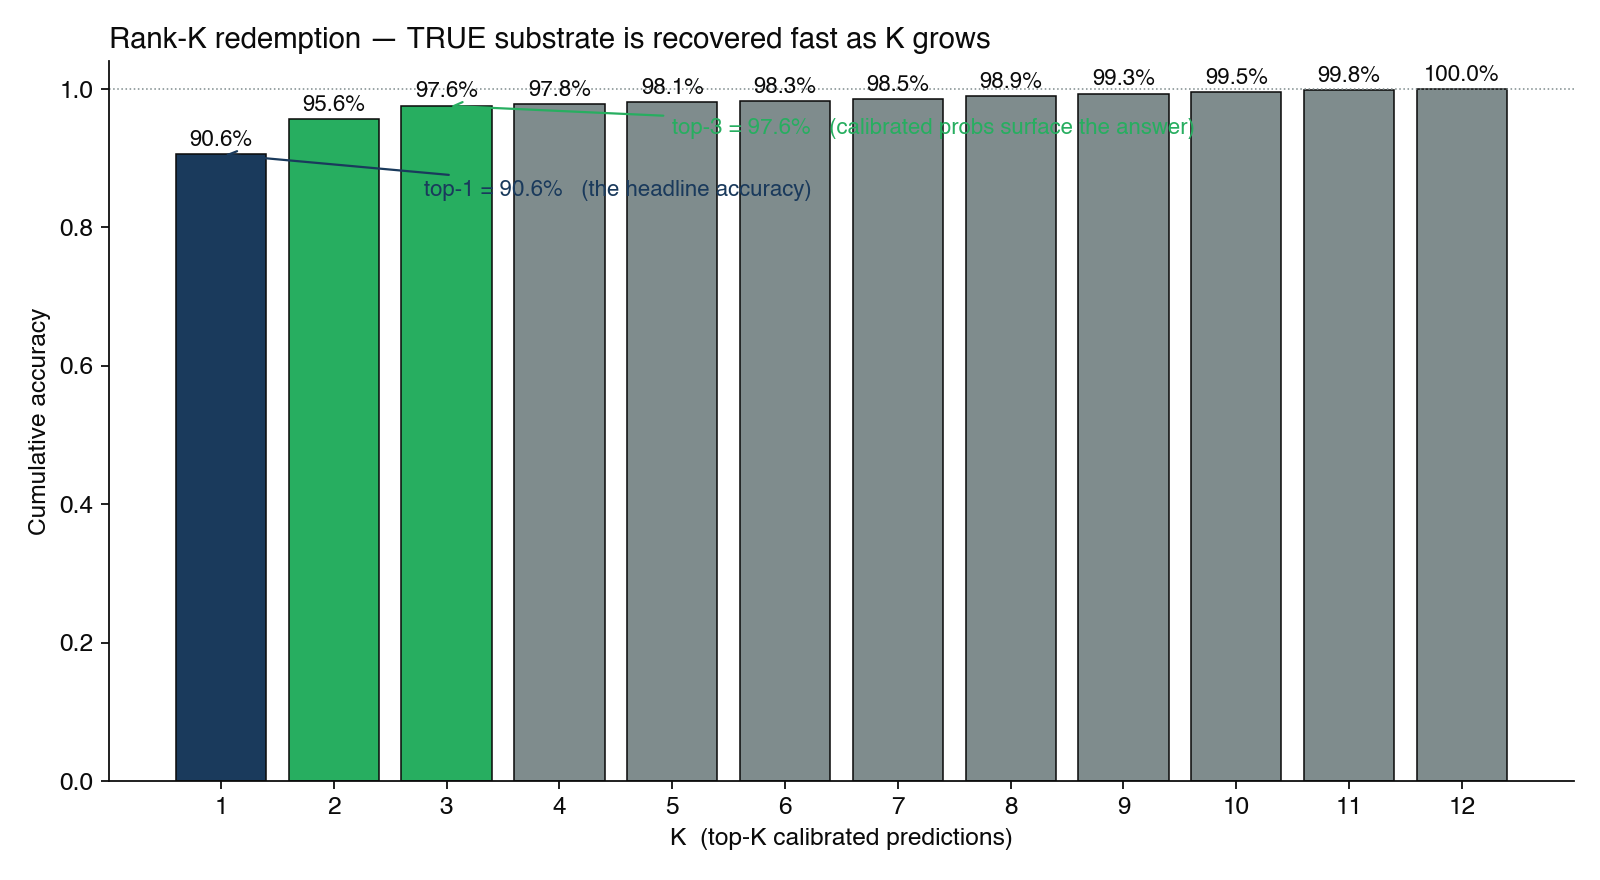


--- Calibrated confidence vs correctness (10-bin reliability) ---


,bin_lo,bin_hi,n_correct,n_incorrect,n_total,pct_correct
0,0.0,0.1,0,0,0,0.0000
1,0.1,0.2,0,0,0,0.0000
2,0.2,0.3,11,6,17,0.6471
3,0.3,0.4,19,14,33,0.5758
4,0.4,0.5,29,25,54,0.5370
5,0.5,0.6,63,14,77,0.8182
6,0.6,0.7,76,9,85,0.8941
7,0.7,0.8,59,11,70,0.8429
8,0.8,0.9,110,2,112,0.9821
9,0.9,1.0,566,16,582,0.9725


  ≥0.8 confidence: 676/694 correct = 97.4%


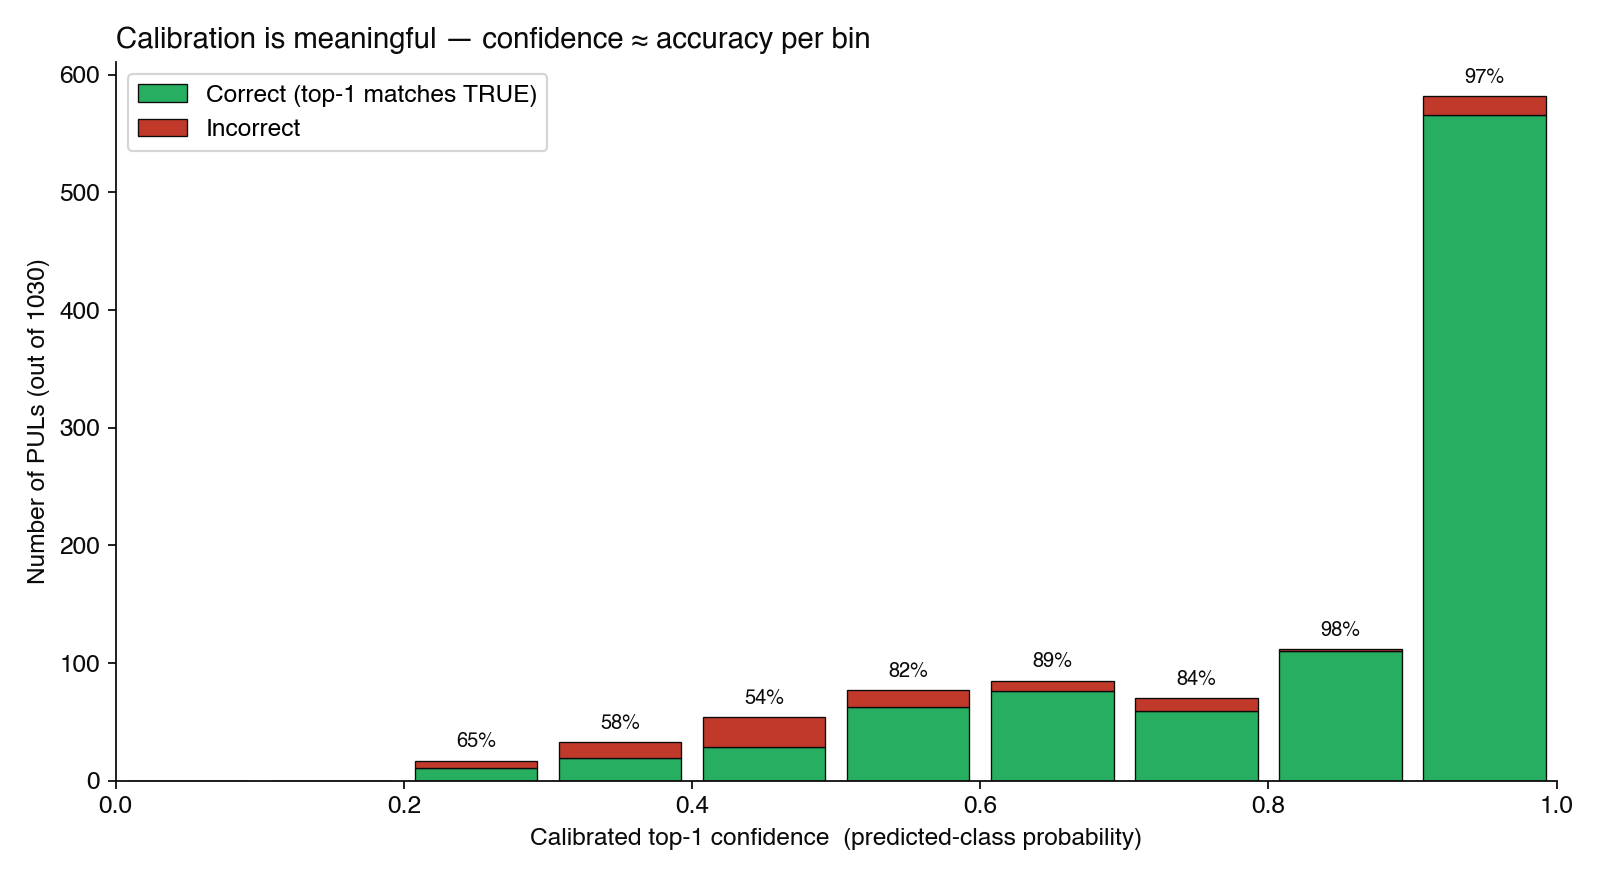


--- 6 hand-picked PUL case studies ---


,pul_idx,scenario_label,true_substrate,top1_pred,top1_conf,true_rank,top3_probs
0,0,Confident + Correct,alginate,alginate,0.962832,1,alginate=0.963; beta-glucan=0.034; chitin=0.001
1,64,TOP-1 wrong → TRUE at rank 2,alpha-glucan,beta-glucan,0.517290,2,beta-glucan=0.517; alpha-glucan=0.318; fructan...
2,136,TOP-1 wrong → TRUE at rank 3,alpha-glucan,fructan,1.000000,3,fructan=1.000; alginate=0.000; alpha-glucan=0.000
3,101,Low-confidence correct (model knows it's unsure),alpha-glucan,alpha-glucan,0.376572,1,alpha-glucan=0.377; beta-glucan=0.323; host gl...
4,7,Medium-confidence correct,alginate,alginate,0.603619,1,alginate=0.604; beta-glucan=0.344; pectin=0.019
5,136,Confident but WRONG (interesting failure case),alpha-glucan,fructan,1.000000,3,fructan=1.000; alginate=0.000; alpha-glucan=0.000


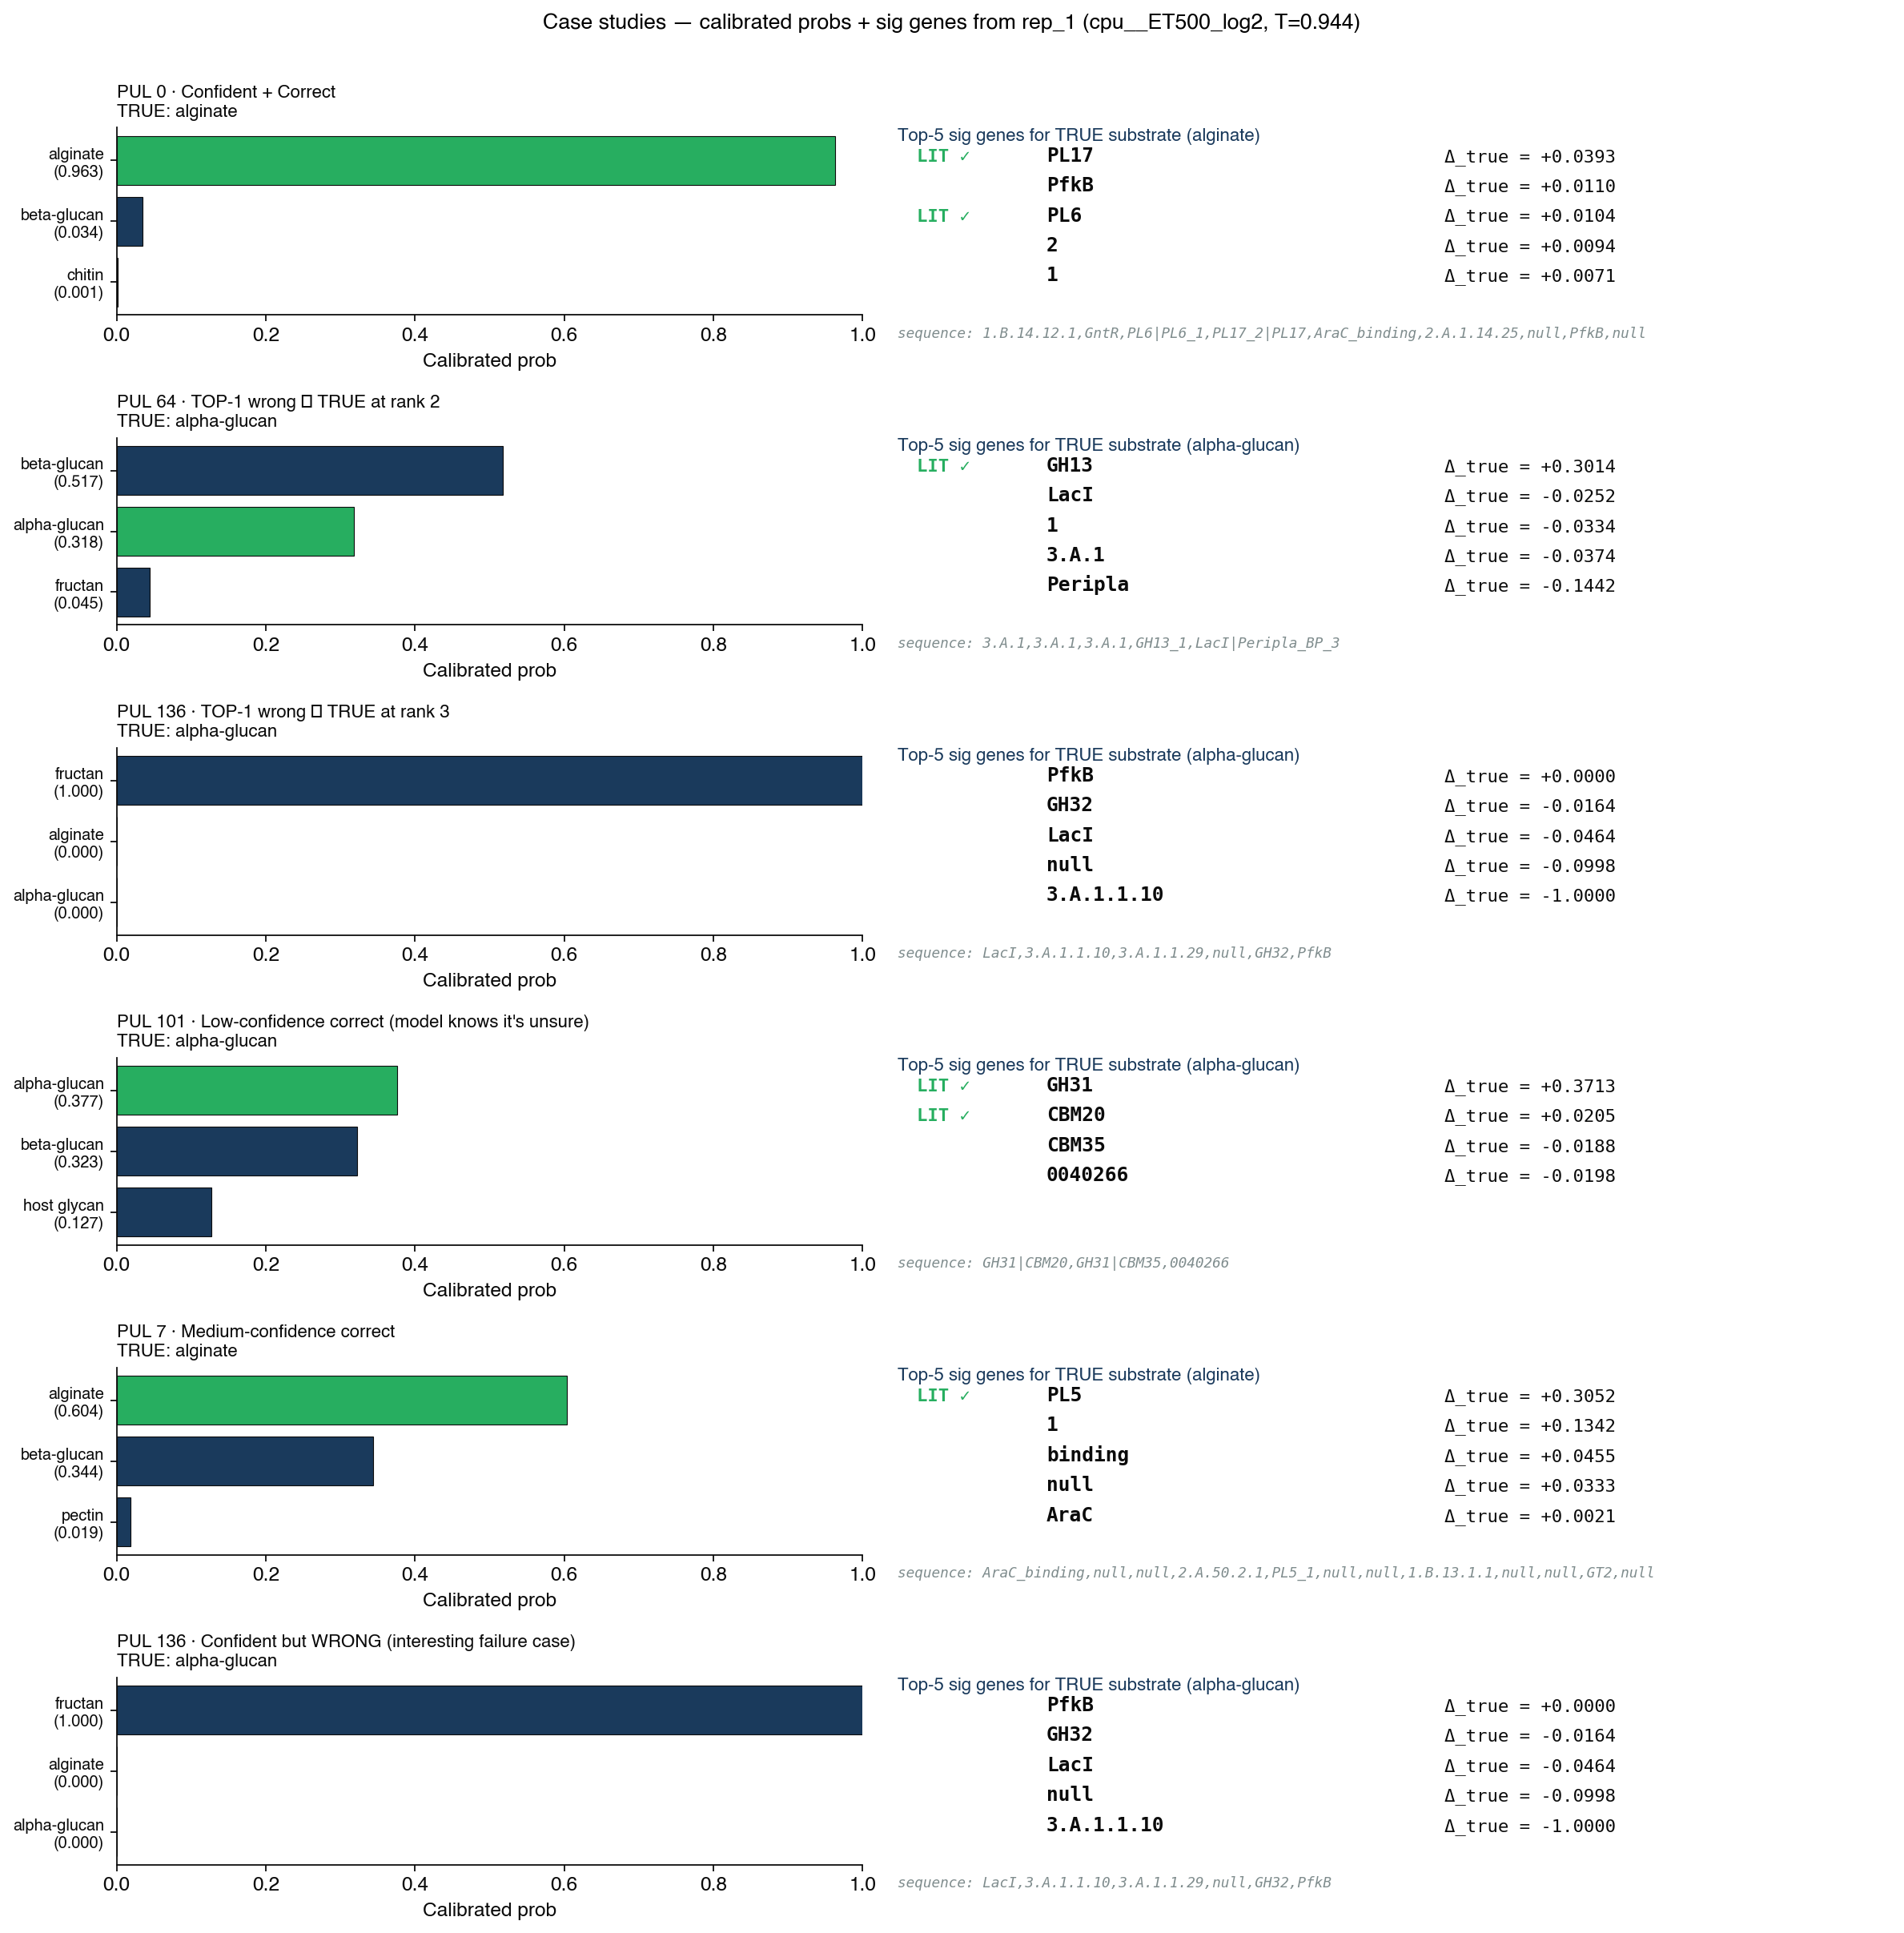

In [15]:
# Section H — load + display case-study artifacts produced by scripts/10_build_case_studies.py
import pandas as pd
from pathlib import Path
from IPython.display import Image, display
DOCS = Path('../docs')

print('--- Rank-K redemption (per substrate, cumulative top-K accuracy) ---')
rank_df = pd.read_csv(DOCS/'tables/tab_rank_redemption.csv')
ntot = rank_df.n_test.sum()
for k in [1, 2, 3, 5]:
    col = f'top{k}_acc'
    overall = (rank_df[col] * rank_df.n_test).sum() / ntot
    print(f'  top-{k} overall = {overall:.4f}')
display(rank_df)
display(Image(filename=str(DOCS/'figures/fig11_rank_redemption.png')))

print('\n--- Calibrated confidence vs correctness (10-bin reliability) ---')
conf_df = pd.read_csv(DOCS/'tables/tab_confidence_vs_correct.csv')
display(conf_df)
high = conf_df[conf_df.bin_lo >= 0.8]
print(f'  ≥0.8 confidence: {int(high.n_correct.sum())}/{int(high.n_total.sum())} correct = {high.n_correct.sum()/high.n_total.sum():.1%}')
display(Image(filename=str(DOCS/'figures/fig12_confidence_vs_correct.png')))

print('\n--- 6 hand-picked PUL case studies ---')
cs_df = pd.read_csv(DOCS/'tables/tab_case_studies.csv')
display(cs_df[['pul_idx','scenario_label','true_substrate','top1_pred','top1_conf','true_rank','top3_probs']])
display(Image(filename=str(DOCS/'figures/fig13_case_study_cards.png')))


## Section I — Cross-rep reproducibility (5 reps × 25 trials, fixed splits)

Quantifies model uncertainty due to **model-init seed only** — the 5×5 RSKF data splits are held fixed; only `REPRO_REP_SEED` varies (1000/2000/3000/4000/5000).

Produced by `scripts/11_build_cross_rep_stability.py` → `docs/tables/tab_cross_rep_*` + `docs/figures/fig14_cross_rep_stability.png`.


  AUDIT: cross_rep_n_reps = 5
  AUDIT: cross_rep_rep_seeds = 1000/2000/3000/4000/5000
  AUDIT: cross_rep_winner = cpu__ET500_log2
  AUDIT: cross_rep_winner_mean = 0.9063
  AUDIT: cross_rep_winner_std = 0.0006
  AUDIT: cross_rep_winner_min = 0.9052
  AUDIT: cross_rep_winner_max = 0.9068
  AUDIT: cross_rep_runner = ftCbow_MM__ET500_sqrt
  AUDIT: cross_rep_runner_mean = 0.9007
  AUDIT: cross_rep_runner_std = 0.0006
  AUDIT: cross_rep_top7_stability = 5/7 ranks identical across all 5 reps
  AUDIT: cross_rep_configs_complete = 21/29 configs have 25 trials in every rep

Winner (cpu__ET500_log2): 0.9063 ± 0.0006
  range [0.9052, 0.9068] over 5 reps
  per-rep means: {'rep_1': 0.9066, 'rep_2': 0.9068, 'rep_3': 0.9064, 'rep_4': 0.9064, 'rep_5': 0.9052}
Runner-up (ftCbow_MM__ET500_sqrt): 0.9007 ± 0.0006
Top-7 ranking: 5/7 ranks identical across all 5 reps

--- Per-config 5-rep matrix (top 10 by rep_1) ---


,shorthand,rep_1_mean,rep_2_mean,rep_3_mean,rep_4_mean,rep_5_mean,cross_rep_mean,cross_rep_std
0,cpu__ET500_log2,0.9066,0.9068,0.9064,0.9064,0.9052,0.9063,0.0006
1,ftCbow_MM__ET500_sqrt,0.9010,0.9012,0.9000,0.9002,0.9012,0.9007,0.0006
2,cv__BRF100,0.8402,0.8412,0.8390,0.8433,0.8435,0.8414,0.0019
3,ftCbow__BRF100,0.8301,0.8328,0.8305,0.8282,0.8313,0.8306,0.0017
4,w2vSg__BRF100,0.8169,0.8179,0.8184,0.8188,0.8196,0.8183,0.0010
5,ftSg__BRF100,0.8148,0.8150,0.8093,0.8146,0.8105,0.8128,0.0027
6,w2vCbow__BRF100,0.8095,0.8054,0.8175,0.8070,0.8099,0.8099,0.0046
7,ftCbow__LSTMattn,0.7883,0.7839,0.7878,0.7909,0.7915,0.7885,0.0030
8,ftSg__LSTMattn,0.7860,0.7903,0.7917,0.7950,0.7806,0.7887,0.0055
9,d2vDm__BRF100,0.7825,0.7849,0.7806,0.7821,0.7773,0.7815,0.0028



--- Top-7 rank by rep ---


,1,2,3,4,5
rank,,,,,
1,cpu__ET500_log2,cpu__ET500_log2,cpu__ET500_log2,cpu__ET500_log2,cpu__ET500_log2
2,ftCbow_MM__ET500_sqrt,ftCbow_MM__ET500_sqrt,ftCbow_MM__ET500_sqrt,ftCbow_MM__ET500_sqrt,ftCbow_MM__ET500_sqrt
3,cv__BRF100,cv__BRF100,cv__BRF100,cv__BRF100,cv__BRF100
4,ftCbow__BRF100,ftCbow__BRF100,ftCbow__BRF100,ftCbow__BRF100,ftCbow__BRF100
5,w2vSg__BRF100,w2vSg__BRF100,w2vSg__BRF100,w2vSg__BRF100,w2vSg__BRF100
6,ftSg__BRF100,ftSg__BRF100,w2vCbow__BRF100,ftSg__BRF100,ftSg__BRF100
7,w2vCbow__BRF100,w2vCbow__BRF100,ftSg__BRF100,w2vCbow__BRF100,w2vCbow__BRF100


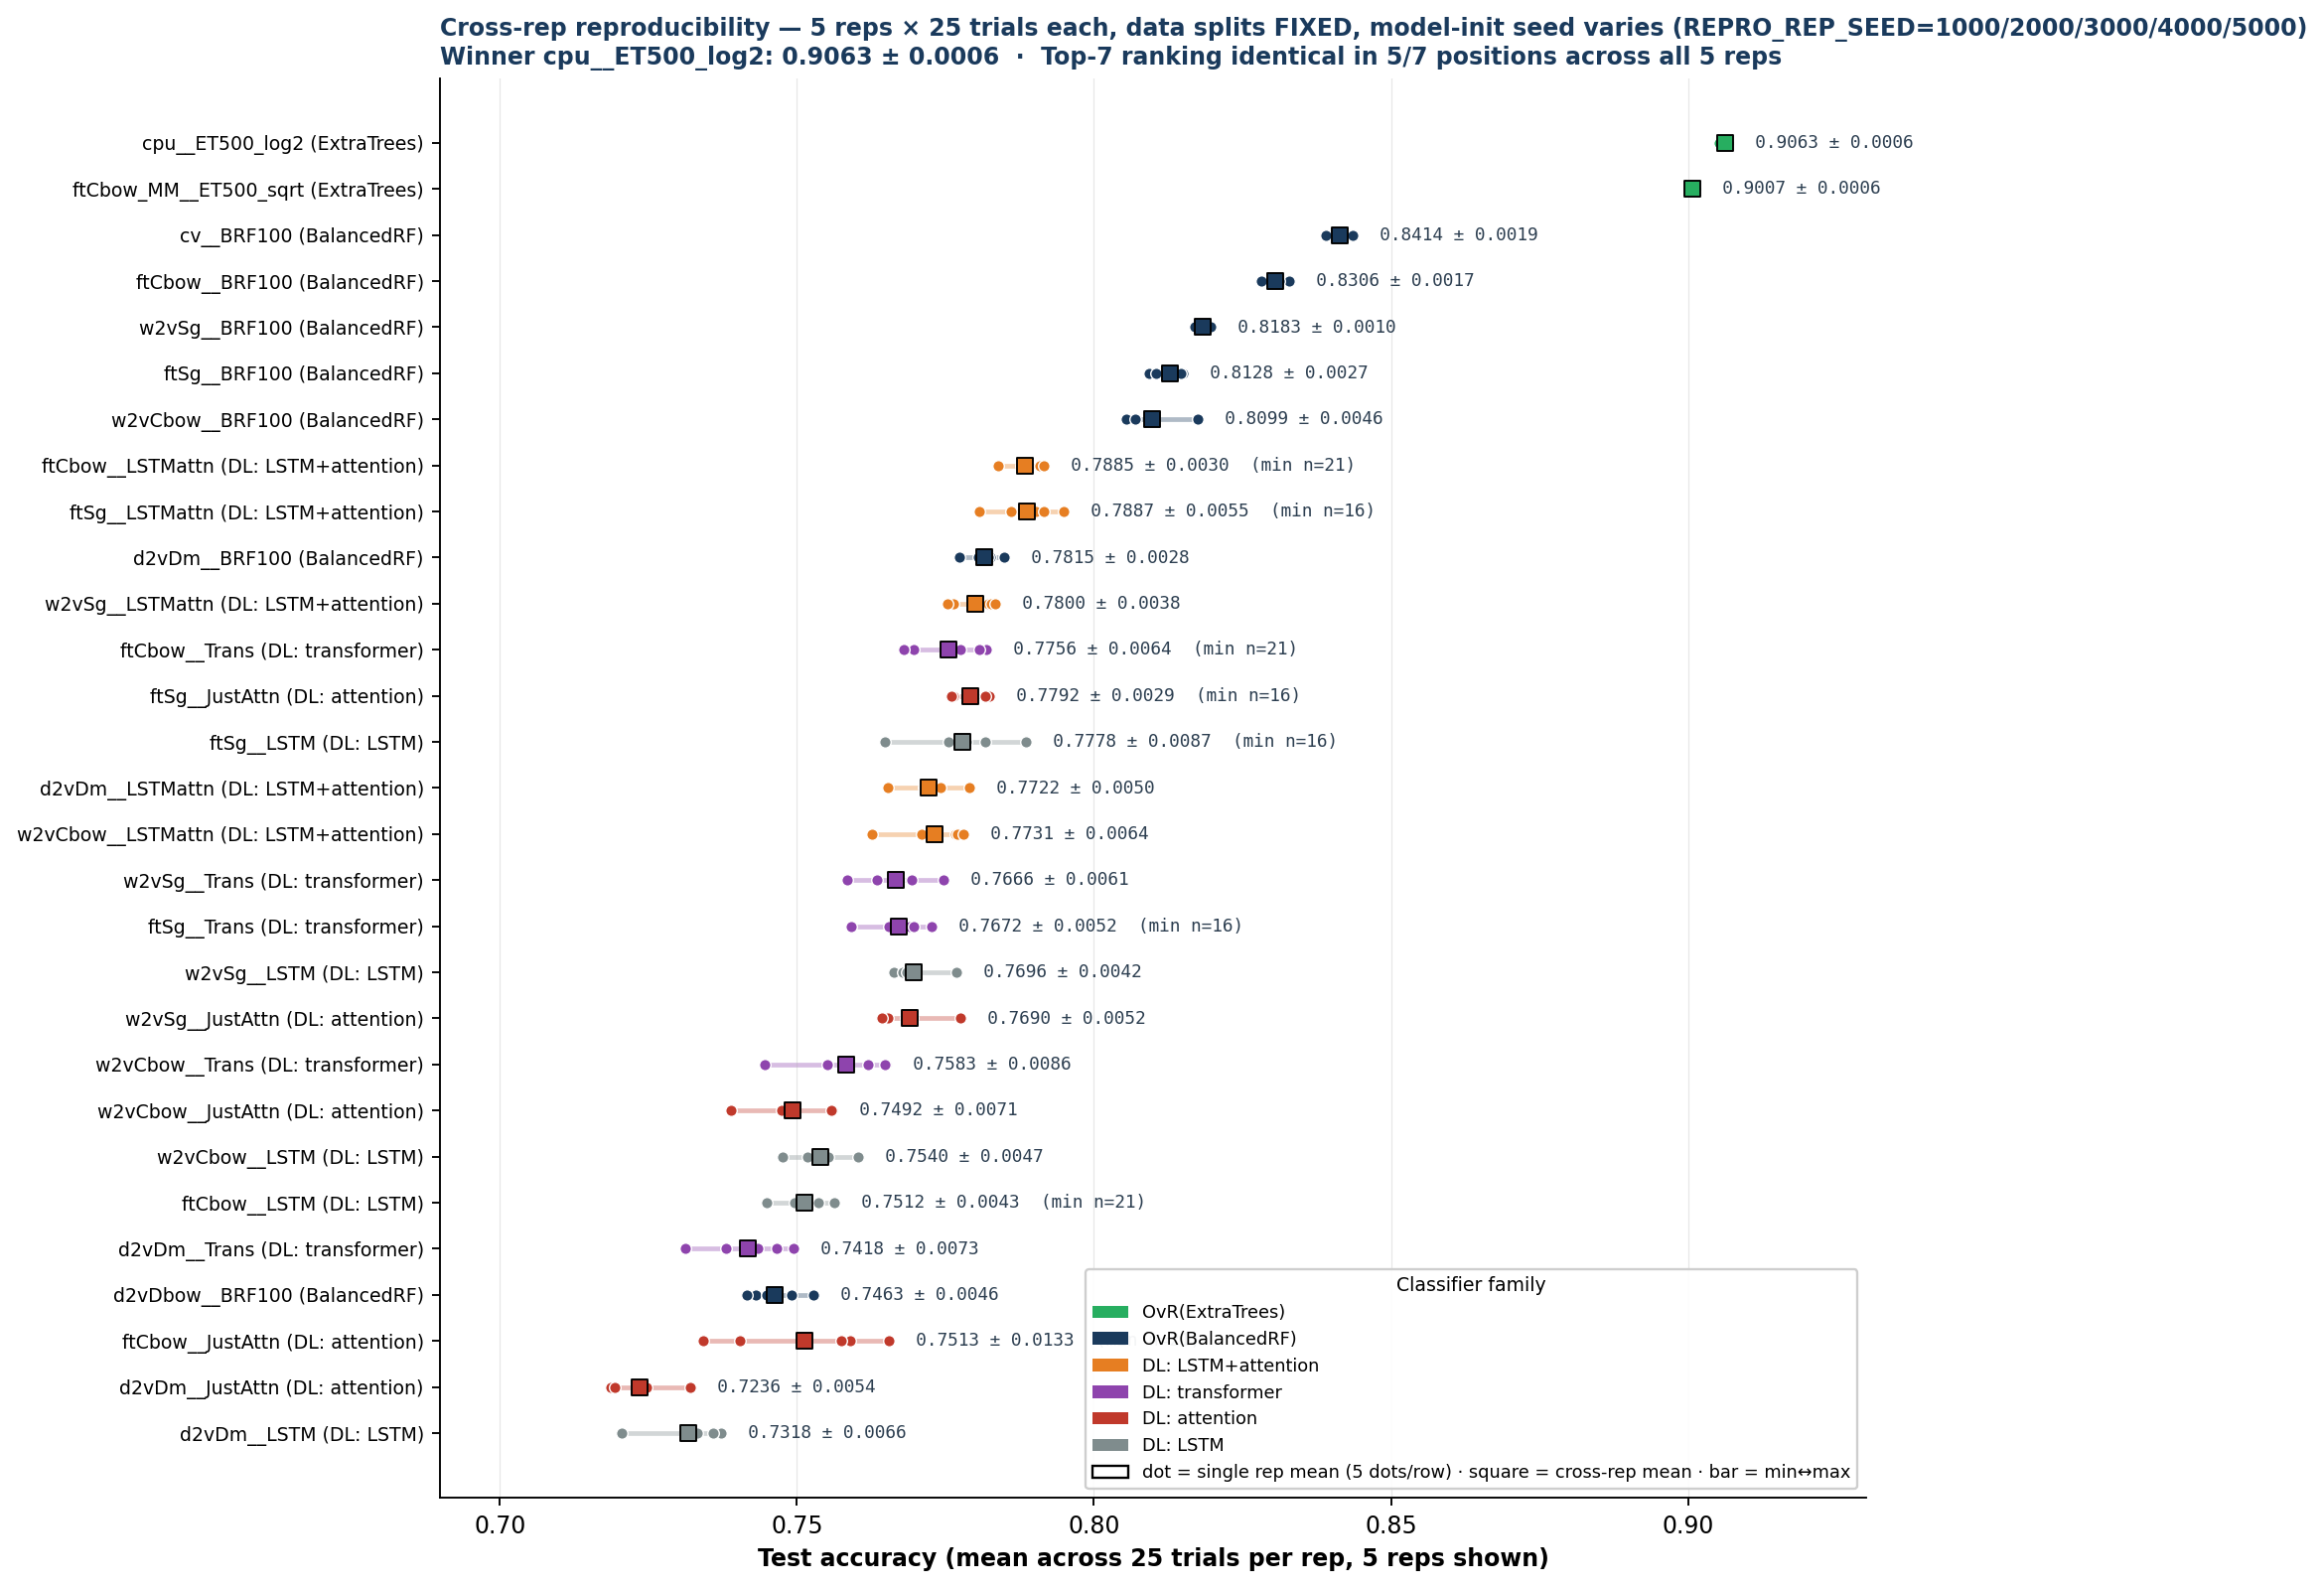

In [16]:
# Section I — load + display cross-rep stability artifacts + log to audit
import json, pandas as pd
from pathlib import Path
from IPython.display import Image, display
DOCS = Path('../docs')

summary = json.loads((DOCS/'tables/tab_cross_rep_summary.json').read_text())
audit('cross_rep_n_reps',         summary['n_reps'])
audit('cross_rep_rep_seeds',      '/'.join(str(x) for x in summary['rep_seeds']))
audit('cross_rep_winner',         summary['winner_config'])
audit('cross_rep_winner_mean',    f"{summary['winner_cross_rep_mean']:.4f}")
audit('cross_rep_winner_std',     f"{summary['winner_cross_rep_std']:.4f}")
audit('cross_rep_winner_min',     f"{summary['winner_cross_rep_min']:.4f}")
audit('cross_rep_winner_max',     f"{summary['winner_cross_rep_max']:.4f}")
audit('cross_rep_runner',         summary['runner_config'])
audit('cross_rep_runner_mean',    f"{summary['runner_cross_rep_mean']:.4f}")
audit('cross_rep_runner_std',     f"{summary['runner_cross_rep_std']:.4f}")
audit('cross_rep_top7_stability', summary['top7_rank_stability'])
audit('cross_rep_configs_complete', f"{summary['n_configs_min_n_25']}/29 configs have 25 trials in every rep")

print(f"\nWinner ({summary['winner_config']}): {summary['winner_cross_rep_mean']:.4f} ± {summary['winner_cross_rep_std']:.4f}")
print(f"  range [{summary['winner_cross_rep_min']:.4f}, {summary['winner_cross_rep_max']:.4f}] over {summary['n_reps']} reps")
print(f"  per-rep means: {summary['winner_per_rep_means']}")
print(f"Runner-up ({summary['runner_config']}): {summary['runner_cross_rep_mean']:.4f} ± {summary['runner_cross_rep_std']:.4f}")
print(f"Top-7 ranking: {summary['top7_rank_stability']}")

print('\n--- Per-config 5-rep matrix (top 10 by rep_1) ---')
xrep = pd.read_csv(DOCS/'tables/tab_cross_rep_stability.csv')
display(xrep.head(10)[['shorthand','rep_1_mean','rep_2_mean','rep_3_mean','rep_4_mean','rep_5_mean','cross_rep_mean','cross_rep_std']])

print('\n--- Top-7 rank by rep ---')
ranks = pd.read_csv(DOCS/'tables/tab_cross_rep_top7_ranking.csv', index_col='rank')
display(ranks)
display(Image(filename=str(DOCS/'figures/fig14_cross_rep_stability.png')))


## Section G — Audit trail

Writes `paper/audit_output.txt` with one line per numeric claim in the paper. Each row in the paper's main text and tables references a key here, so a reader can verify every number.


## Write audit_output.txt for traceability

In [17]:
with open(f'{PAPER}/audit_output.txt', 'w') as fp:
    fp.write('# Paper audit output — every numeric claim traceable\n')
    fp.write('# Generated by build_paper_artifacts.ipynb\n')
    fp.write('\n'.join(AUDIT_LINES))
    fp.write('\n')
print(f'Saved {len(AUDIT_LINES)} audit lines to {PAPER}/audit_output.txt')

Saved 74 audit lines to /Users/ved/subFinder_May_Release/paper/audit_output.txt
